<!-- COVER PAGE -->
<div style="text-align:center; margin-top:100px; margin-bottom:100px">
    <h1 style="font-size:48px; font-weight:bold;">📘 Credit Scoring en Afrique de l'Ouest</h1>
    <h2 style="font-weight:normal;">Modélisation prédictive du risque de crédit</h2>
    <p style="font-size:18px; margin-top:40px;">Par Kodjo Jean DEGBEVI</p>
    <p style="font-size:14px;">Octobre 2025</p>
</div>

<div style="text-align: center; margin-bottom: 20px;">
  <img src="../Docs/Image/CSWA.png" alt="Logo" style="width: 200px;">
</div>



# HEAD

<h2> <u>Table des matières</u> </h2>

- [Chargement des données](#collecte-et-premieres-observations)
- [Analyse de la forme](#analyse-de-la-forme)
- [Analyse du fond](#analyse-du-fond)
- [Préparation des données pour l'entraînement](#preparation-des-donnees-pour-lentrainement)
- [Modélisation, entraînement et évaluation](#modelisation-entrainement-et-evaluation)
- [Prédictions sur de nouvelles données](#predictions-sur-de-nouvelles-donnees)


| Nom de la variable            | Type        | Description                                                           |
| ----------------------------- | ----------- | --------------------------------------------------------------------- |
| `ID`                          | Identifiant | Identifiant unique de l’enregistrement                                |
| `customer_id`                 | Identifiant | Identifiant unique du client emprunteur                               |
| `country_id`                  | Identifiant | Identifiant du pays (permet de croiser avec une table pays, si dispo) |
| `tbl_loan_id`                 | Identifiant | Identifiant du prêt dans la table principale des prêts                |
| `lender_id`                   | Identifiant | Identifiant du prêteur associé au prêt                                |
| `loan_type`                   | Catégoriel  | Type de prêt (ex : "business", "personal", etc.)                      |
| `Total_Amount`                | Numérique   | Montant total du prêt demandé                                         |
| `Total_Amount_to_Repay`       | Numérique   | Montant total que l’emprunteur doit rembourser (avec intérêts/frais)  |
| `disbursement_date`           | Date        | Date de décaissement du prêt                                          |
| `due_date`                    | Date        | Date d’échéance du remboursement                                      |
| `duration`                    | Numérique   | Durée du prêt (en jours ou mois)                                      |
| `New_versus_Repeat`           | Catégoriel  | Statut du client : nouveau ou récurrent                               |
| `Amount_Funded_By_Lender`     | Numérique   | Montant réellement financé par le prêteur                             |
| `Lender_portion_Funded`       | Numérique   | Part du montant total financé par ce prêteur                          |
| `Lender_portion_to_be_repaid` | Numérique   | Part du remboursement revenant au prêteur                             |
| `target`                      | Binaire     | Variable cible : défaut (1) ou non défaut (0)                         |


In [1]:
import sys
import os
import importlib
import time
import pandas as pd
from pandas.api.types import CategoricalDtype
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import missingno as mns
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc
from sklearn.metrics import make_scorer, fbeta_score

from sklearn.ensemble import StackingClassifier
#sklearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import StratifiedKFold, cross_val_score

import shap
from tqdm import tqdm
import joblib

/run/media/kjd/working/projects/IA/CreditRisk/CreditRiskScoring/creditriskscoringvenv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Collecte et premières observations

In [115]:
data = pd.read_csv("../Data/Train.csv")
df = data.copy()
df.sample(10)

,ID,customer_id,country_id,tbl_loan_id,lender_id,loan_type,Total_Amount,Total_Amount_to_Repay,disbursement_date,due_date,duration,New_versus_Repeat,Amount_Funded_By_Lender,Lender_portion_Funded,Lender_portion_to_be_repaid,target
55204,ID_250718235948267278,250718,Kenya,235948,267278,Type_1,15947.0,16140.0,2022-08-12,2022-08-19,7,Repeat Loan,4784.10,0.30000,4842.0,0
47415,ID_308884372525251804,308884,Kenya,372525,251804,Type_7,6500.0,6728.0,2024-10-04,2024-10-11,7,Repeat Loan,1300.00,0.20000,1346.0,0
61759,ID_115025223705267278,115025,Kenya,223705,267278,Type_1,28460.0,29313.0,2022-07-25,2022-08-01,7,Repeat Loan,8538.00,0.30000,8794.0,0
6109,ID_250162248769267278,250162,Kenya,248769,267278,Type_1,27008.0,27487.0,2022-08-31,2022-09-07,7,Repeat Loan,0.00,0.00000,0.0,0
62903,ID_259110223111267278,259110,Kenya,223111,267278,Type_1,5199.0,5199.0,2022-07-23,2022-07-30,7,Repeat Loan,1559.70,0.30000,1560.0,0
42924,ID_259032232269267278,259032,Kenya,232269,267278,Type_1,1600.0,1612.0,2022-08-05,2022-08-12,7,Repeat Loan,480.00,0.30000,484.0,0
56470,ID_261462243947267278,261462,Kenya,243947,267278,Type_1,355.0,361.0,2022-08-25,2022-09-01,7,Repeat Loan,106.50,0.30000,108.0,0
41996,ID_260147246423267278,260147,Kenya,246423,267278,Type_1,4799.0,4799.0,2022-08-29,2022-09-05,7,Repeat Loan,1439.70,0.30000,1440.0,0
15673,ID_239580293920267278,239580,Kenya,293920,267278,Type_1,2020.0,2020.0,2022-11-04,2022-11-11,7,Repeat Loan,606.00,0.30000,606.0,0
61132,ID_260068292250267278,260068,Kenya,292250,267278,Type_1,20139.0,20260.0,2022-11-01,2022-11-08,7,Repeat Loan,1848.56,0.09179,1860.0,0


In [116]:
print(df.shape)

(68654, 16)


In [117]:
print(df.columns)

Index(['ID', 'customer_id', 'country_id', 'tbl_loan_id', 'lender_id',
       'loan_type', 'Total_Amount', 'Total_Amount_to_Repay',
       'disbursement_date', 'due_date', 'duration', 'New_versus_Repeat',
       'Amount_Funded_By_Lender', 'Lender_portion_Funded',
       'Lender_portion_to_be_repaid', 'target'],
      dtype='object')


In [118]:
df.describe()

,customer_id,tbl_loan_id,lender_id,Total_Amount,Total_Amount_to_Repay,duration,Amount_Funded_By_Lender,Lender_portion_Funded,Lender_portion_to_be_repaid,target
count,68654.000000,68654.000000,68654.000000,6.865400e+04,6.865400e+04,68654.000000,6.865400e+04,68654.000000,6.865400e+04,68654.000000
mean,254390.256780,263056.266248,266420.528462,1.483683e+04,1.563993e+04,8.544586,2.545663e+03,0.218679,2.652621e+03,0.018324
std,26642.719918,39486.661487,3590.999004,1.416499e+05,1.650784e+05,13.343145,1.192272e+04,0.129832,1.338006e+04,0.134120
min,145.000000,101323.000000,245684.000000,2.000000e+00,0.000000e+00,1.000000,0.000000e+00,0.000000,0.000000e+00,0.000000
25%,248945.750000,233942.250000,267278.000000,2.295000e+03,2.329000e+03,7.000000,2.340000e+02,0.118712,2.390000e+02,0.000000
50%,255361.000000,260305.500000,267278.000000,5.249000e+03,5.325000e+03,7.000000,9.150000e+02,0.300000,9.340000e+02,0.000000
75%,262269.250000,286962.750000,267278.000000,1.145000e+04,1.165000e+04,7.000000,2.272650e+03,0.300000,2.317000e+03,0.000000
max,312737.000000,375320.000000,267278.000000,2.300000e+07,2.541500e+07,1096.000000,1.600000e+06,1.168119,1.821338e+06,1.000000


In [119]:
df.describe(include="object")

,ID,country_id,loan_type,disbursement_date,due_date,New_versus_Repeat
count,68654,68654,68654,68654,68654,68654
unique,68654,1,22,768,893,2
top,ID_266671248032267278,Kenya,Type_1,2022-07-16,2022-07-23,Repeat Loan
freq,1,68654,61723,938,940,68087


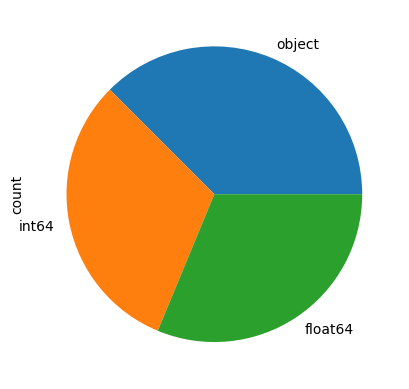

In [120]:
df.dtypes.value_counts().plot.pie()
plt.show()

In [121]:
print(df.dtypes)

ID                              object
customer_id                      int64
country_id                      object
tbl_loan_id                      int64
lender_id                        int64
loan_type                       object
Total_Amount                   float64
Total_Amount_to_Repay          float64
disbursement_date               object
due_date                        object
duration                         int64
New_versus_Repeat               object
Amount_Funded_By_Lender        float64
Lender_portion_Funded          float64
Lender_portion_to_be_repaid    float64
target                           int64
dtype: object


# Analyse de forme

## Missing data

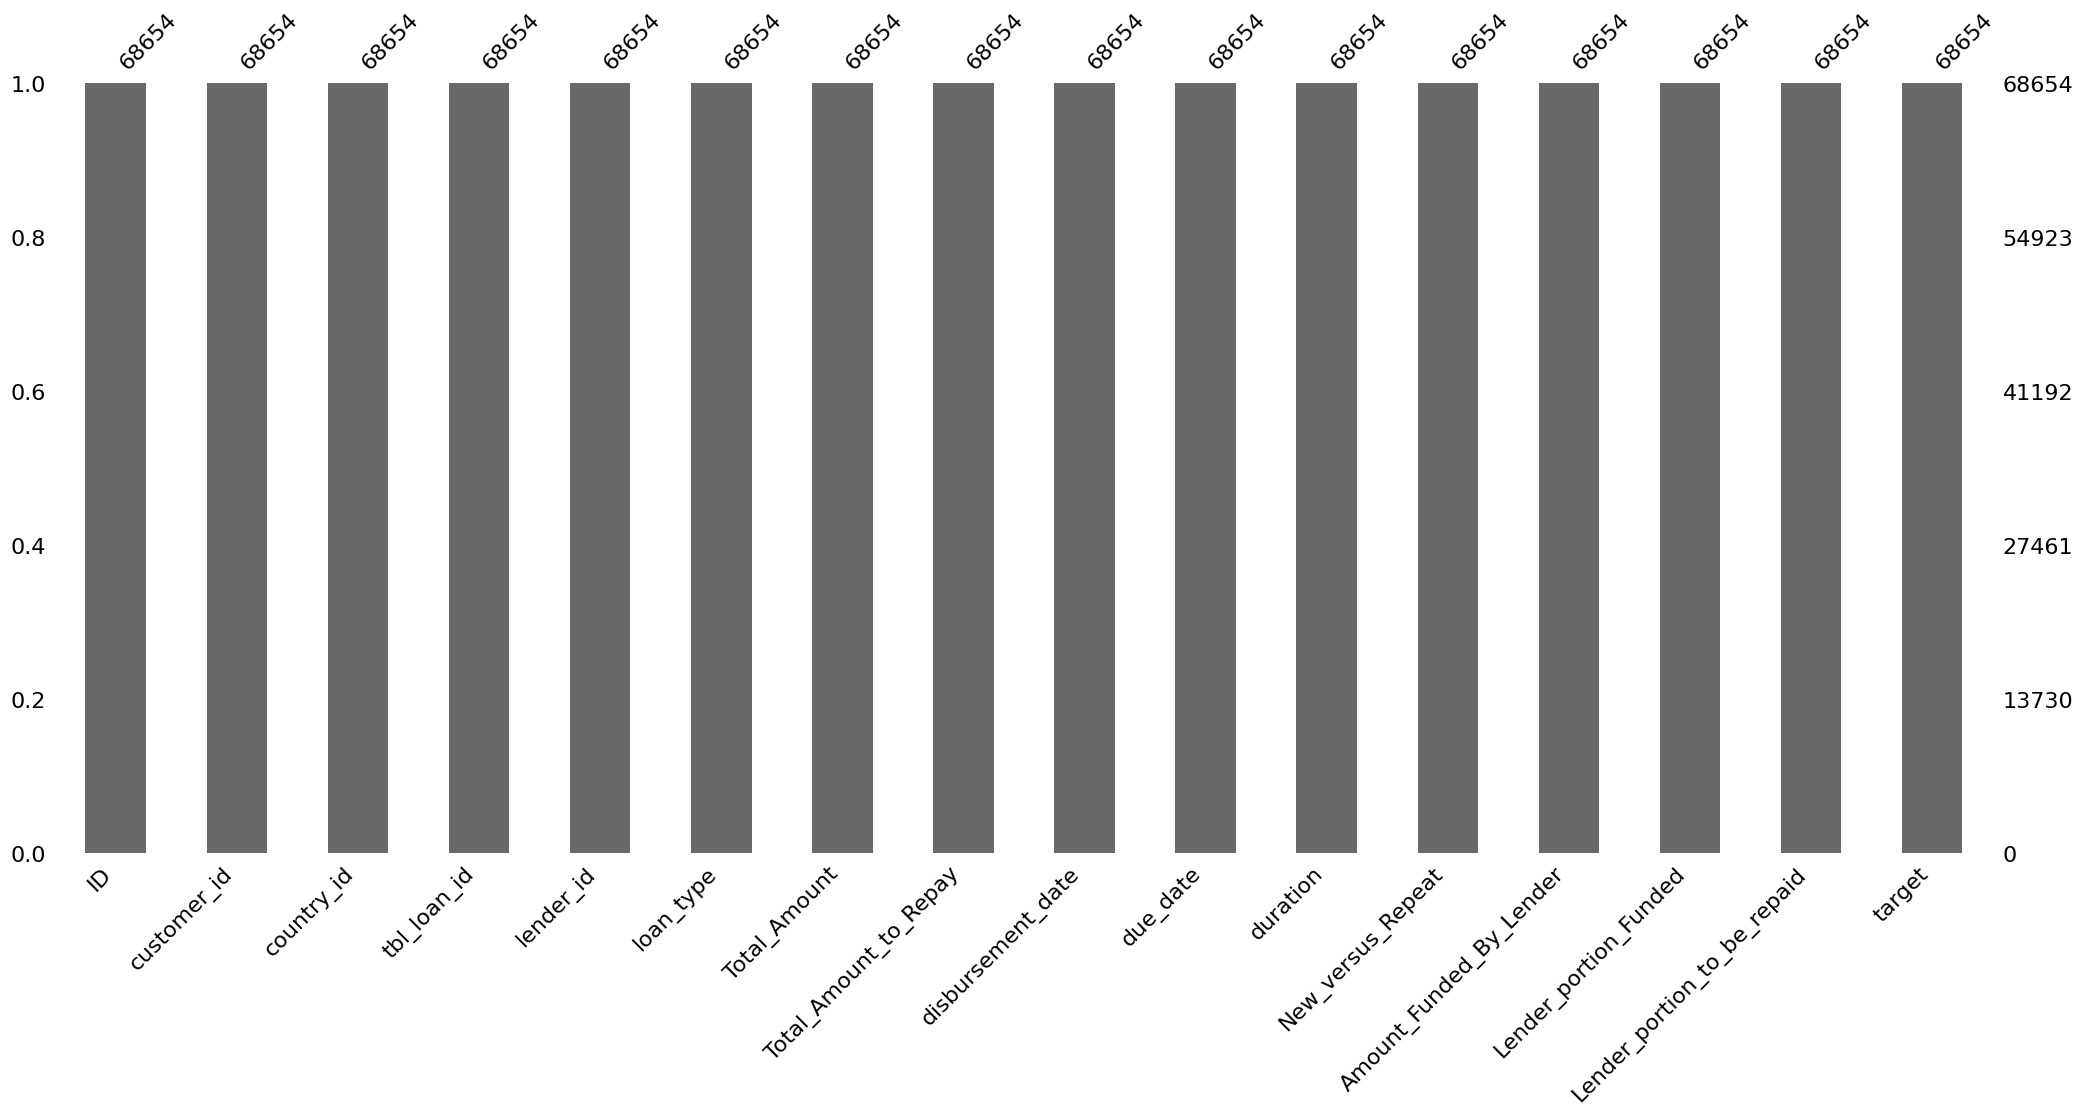

In [27]:
mns.bar(df)
plt.show()

**Pas de valeurs manquantes.**

## S'assurer que les colonnes de date sont en format datetime

In [125]:
df['disbursement_date'] = pd.to_datetime(df['disbursement_date'], errors='coerce')
df['due_date'] = pd.to_datetime(df['due_date'], errors='coerce')

## Créer de variables dérivées 

### Pour mieux capturer les caractéristiques temporelles

In [29]:
df['disbursement_month'] = df['disbursement_date'].dt.month
df['disbursement_dayofweek'] = df['disbursement_date'].dt.dayofweek

### S'assurer que la variable duration est fiable : 

In [131]:
((df['due_date'] - df['disbursement_date']).dt.days - df['duration']).describe()

count    68654.0
mean         0.0
std          0.0
min          0.0
25%          0.0
50%          0.0
75%          0.0
max          0.0
dtype: float64

L'écart est nul donc pas besoin de dériver une nouvelle variable. 

On peut garder duration

### Capturons la charge relative au prêt, le taux d'effort

In [31]:
df['repayment_ratio'] = df['Total_Amount_to_Repay'].divide(df['Total_Amount'])

## Encoder les colonnes catégorielles

In [32]:
Hot_encoder = OneHotEncoder(drop='first', handle_unknown='ignore')
Hot_encoder.fit(df[['New_versus_Repeat']])
encoded_var= pd.DataFrame(Hot_encoder.transform(df[['New_versus_Repeat']]).toarray(), columns=Hot_encoder.get_feature_names_out(['New_versus_Repeat']))
df = pd.concat([df, encoded_var], axis=1)

df_all = pd.concat([data, pd.read_csv("../Data/Test.csv")], axis=0).reset_index(drop=True)
loan_type_dtype = CategoricalDtype(categories=df_all['loan_type'].unique().tolist(), ordered=False)
df['loan_type_encoded'] = df['loan_type'].astype(loan_type_dtype).cat.codes

pd.set_option('display.max_columns', 16)
df.sample(5)

,ID,customer_id,country_id,tbl_loan_id,lender_id,loan_type,Total_Amount,Total_Amount_to_Repay,...,Lender_portion_Funded,Lender_portion_to_be_repaid,target,disbursement_month,disbursement_dayofweek,repayment_ratio,New_versus_Repeat_Repeat Loan,loan_type_encoded
1690,ID_254405219081267278,254405,Kenya,219081,267278,Type_1,25411.0,26186.0,...,0.30,7856.0,0,7,0,1.030499,1.0,0
41535,ID_249309143624251804,249309,Kenya,143624,251804,Type_5,23000.0,24250.0,...,0.16,3880.0,0,4,3,1.054348,1.0,2
18786,ID_243264221688267278,243264,Kenya,221688,267278,Type_1,6829.0,6871.0,...,0.30,2061.0,0,7,4,1.006150,1.0,0
64815,ID_263934255330267278,263934,Kenya,255330,267278,Type_1,15859.0,15962.0,...,0.30,4789.0,0,9,4,1.006495,1.0,0
21425,ID_258362266791267278,258362,Kenya,266791,267278,Type_1,995.0,1024.0,...,0.30,307.0,0,9,5,1.029146,1.0,0


## Supprimer les colonnes inutiles

In [33]:
cols_to_drop = [
    'ID', 'customer_id', 'lender_id', 'tbl_loan_id', 'disbursement_date', 'due_date',
    'loan_type', 'New_versus_Repeat', 'country_id'
]
df.drop(columns=cols_to_drop, inplace=True)
print(df.shape)
df.dtypes

(68654, 12)


Total_Amount                     float64
Total_Amount_to_Repay            float64
duration                           int64
Amount_Funded_By_Lender          float64
Lender_portion_Funded            float64
Lender_portion_to_be_repaid      float64
target                             int64
disbursement_month                 int32
disbursement_dayofweek             int32
repayment_ratio                  float64
New_versus_Repeat_Repeat Loan    float64
loan_type_encoded                   int8
dtype: object

# Analyse de fond

In [34]:
del df_all

## Séparation des featrues de la cible

In [35]:
X = df.drop(columns='target')
y = df[['target']]

## Distribution de la cible

In [36]:
y.value_counts(normalize=True) * 100

target
0         98.167623
1          1.832377
Name: proportion, dtype: float64

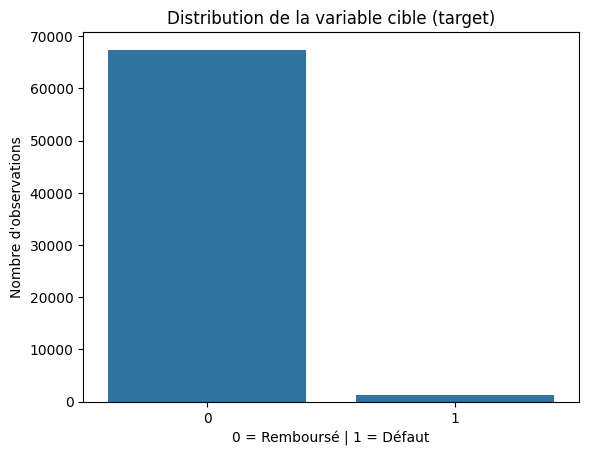

In [37]:
sns.countplot(y, x='target')
plt.title("Distribution de la variable cible (target)")
plt.xlabel("0 = Remboursé | 1 = Défaut")
plt.ylabel("Nombre d'observations")
plt.show()

**Cible très désiquilibrée. On aura peut-être besoin d'une augmentation smote**

## Analyse des features

### Distribution de certaines features

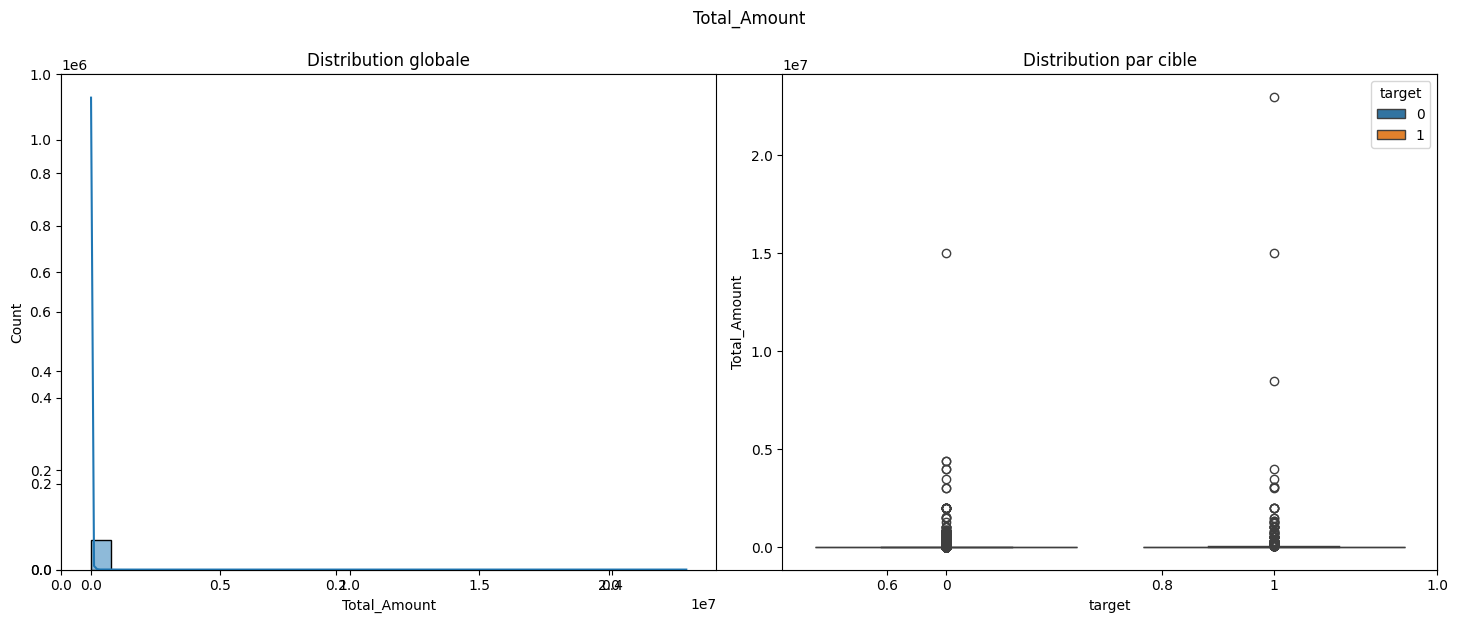

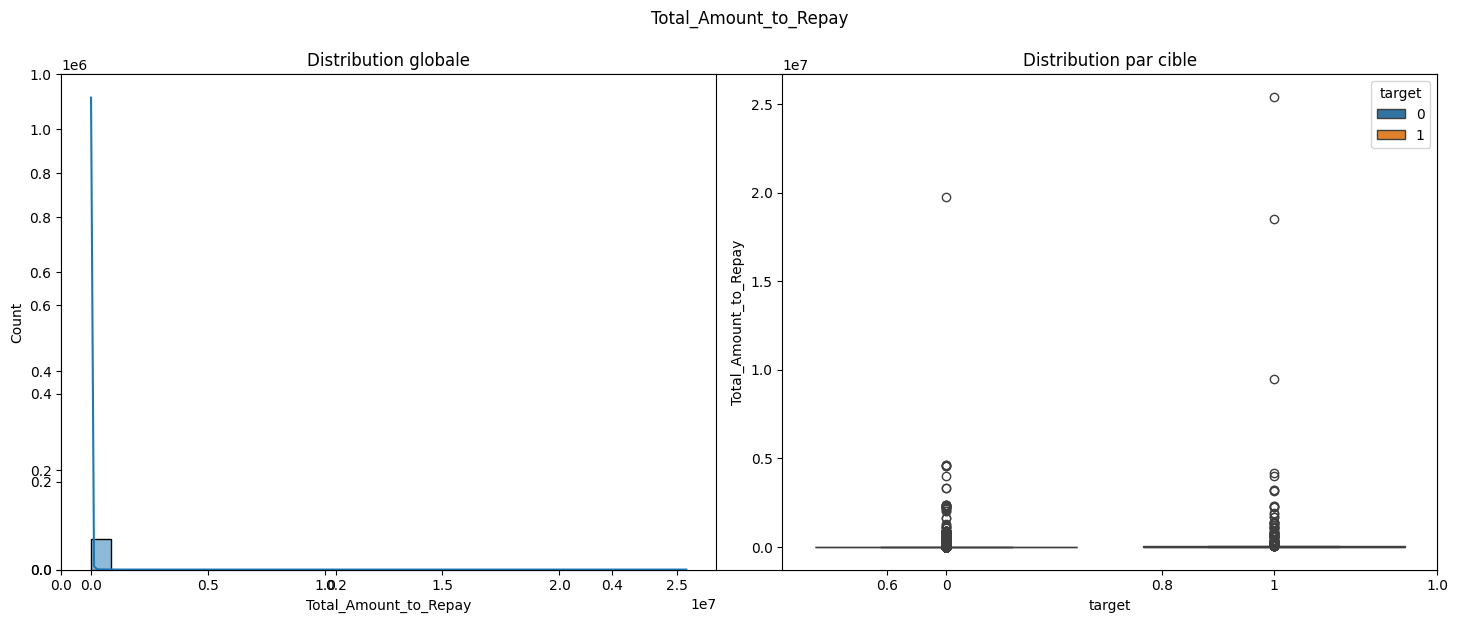

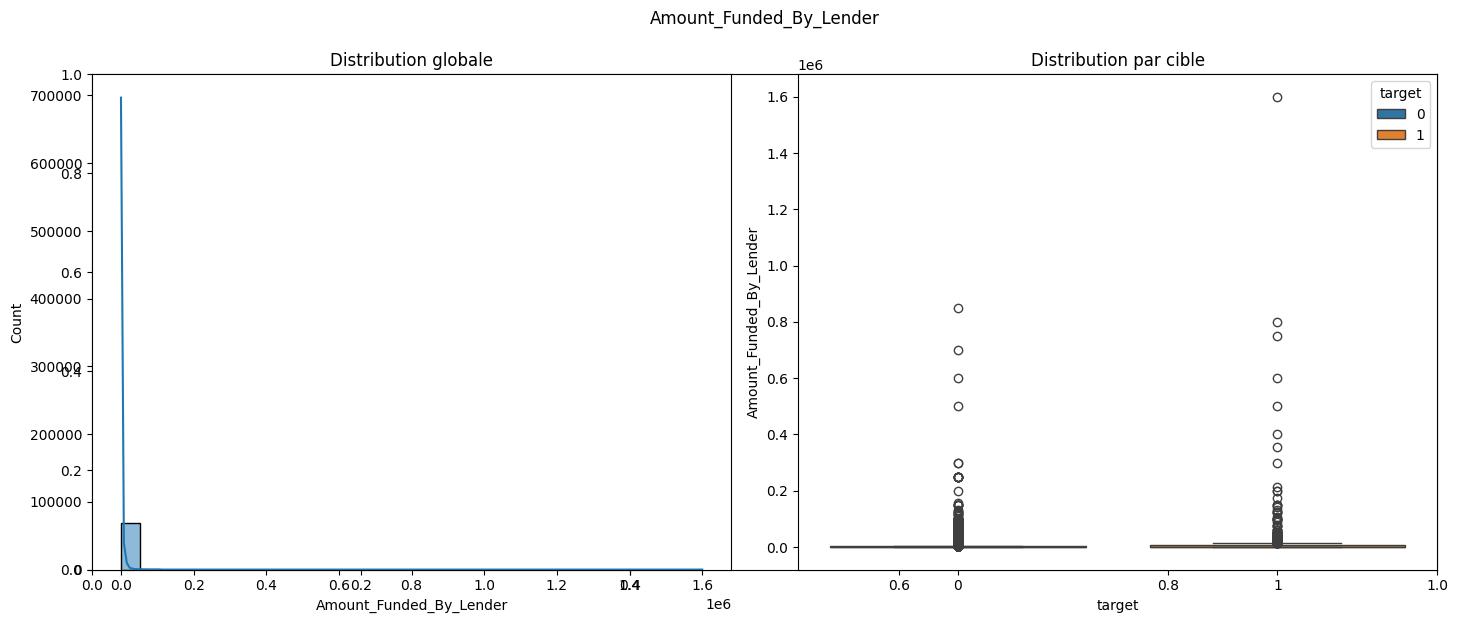

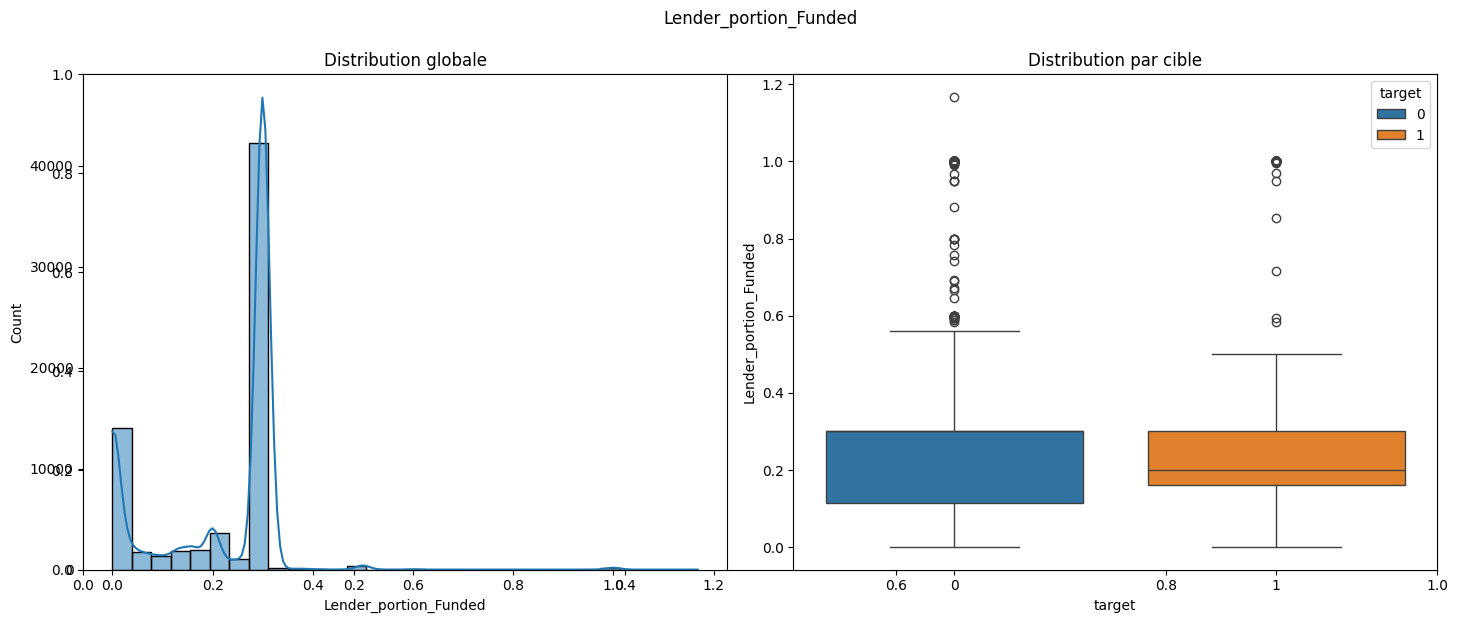

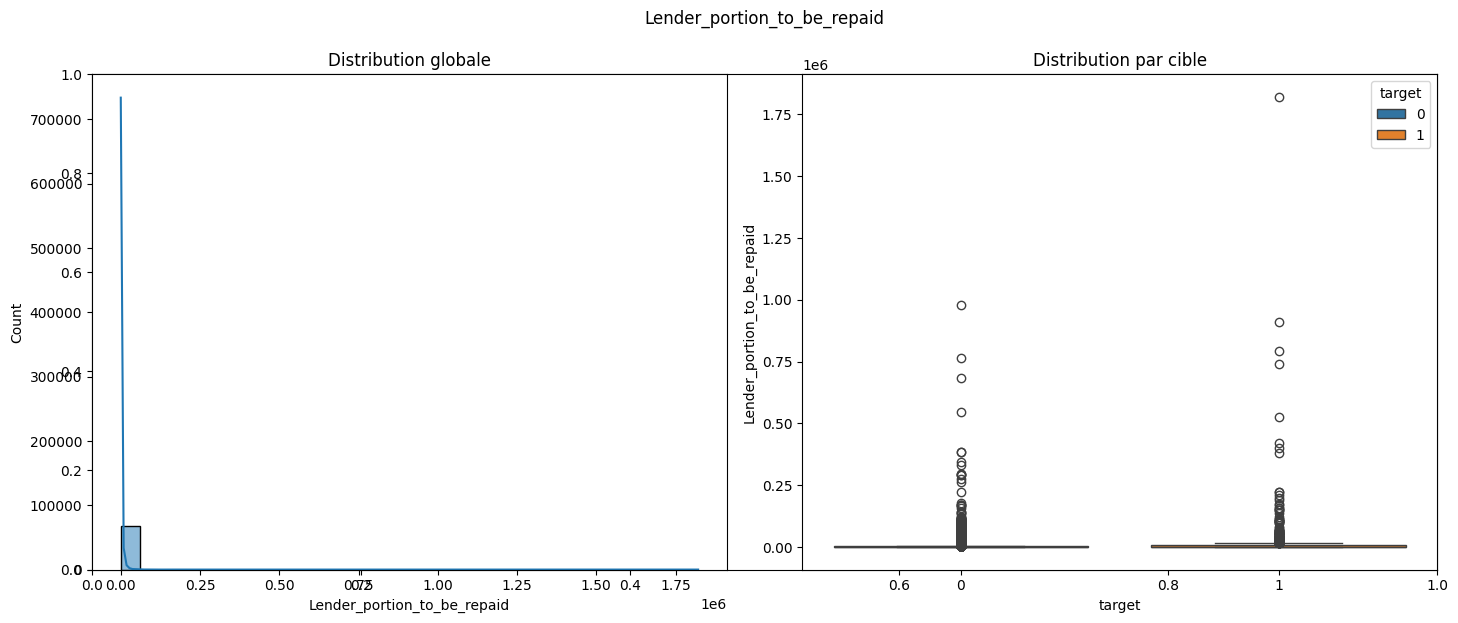

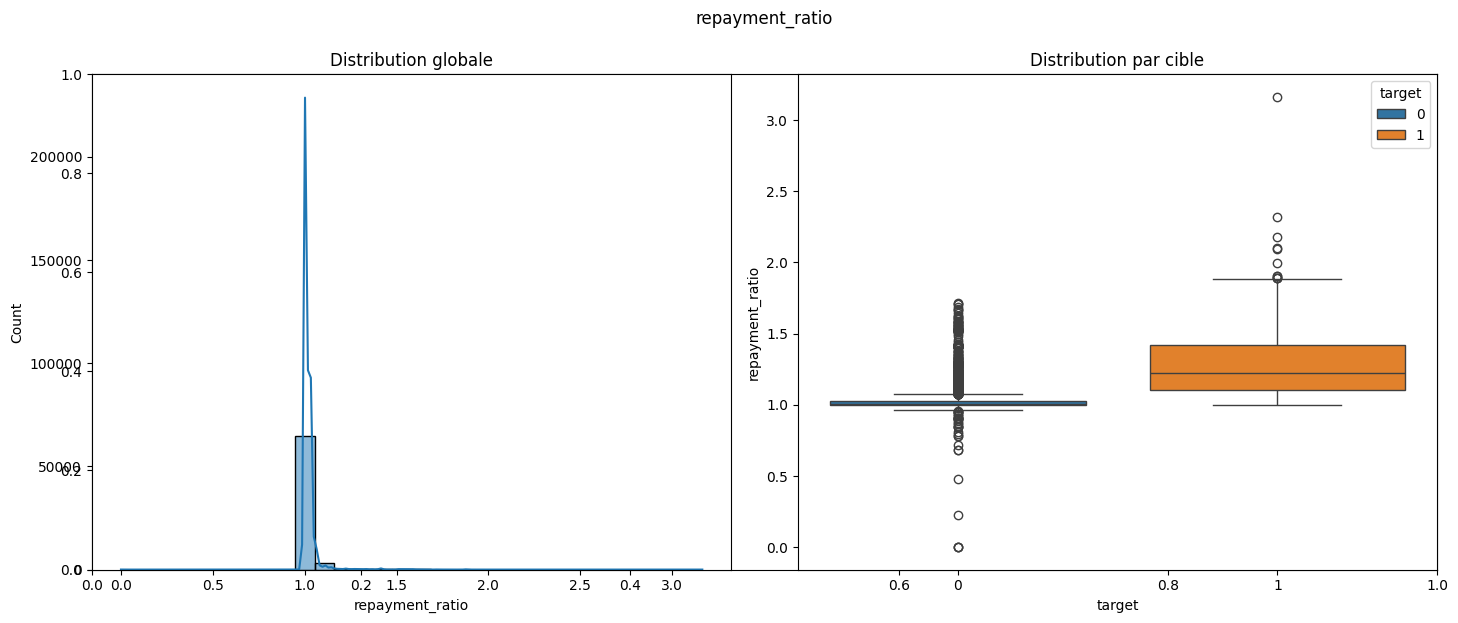

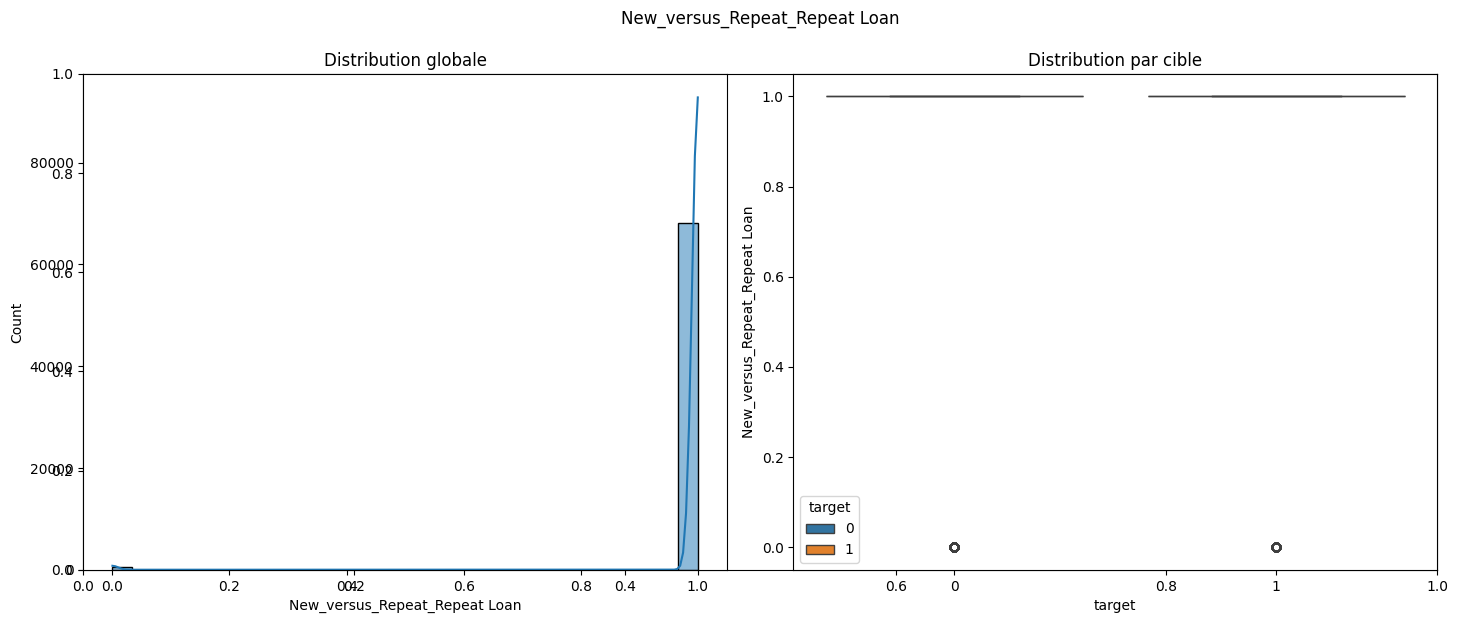

In [38]:
for col in X.select_dtypes(include=['float64']).columns:
    plt.figure(figsize=(15, 7))
    plt.title(f'{col}\n\n', loc='center')

    # Histogramme global
    plt.subplot(1, 2, 1)
    sns.histplot(X[col], kde=True, bins=30)
    plt.title(f'Distribution globale')
    
    # Histogramme par classe (target = 0 ou 1)
    plt.subplot(1, 2, 2)
    #sns.histplot(data=X.assign(target=y), x=col, hue='target', kde=True, bins=30, multiple='stack')
    sns.boxplot(data=X.assign(target=y), x='target', y=col, hue='target')
    plt.title(f'\nDistribution par cible')

    plt.tight_layout()
    plt.show()

* **Les features '*Total_Amount*','*Total_Amount_to_Repay*' et '*Amount_Funded_By_Lender*' suivent pratiquement la même distribution et ne dégagent pas de tendances particulières.**
    * **Par contre, elles présentent beaucoup d'outliers.<br> Nous continuerons avec elles comme cela pour le moment.**
* **'*Lender_portion_Funded*' et *'Lender_portion_to_be_repaid'* aussi présentent d'importants outliers et montre visuellement pas de tendances dans les données.<br> Nous les gardons aussi telles quelles pour le moment.**

* **`Par contre avec *'repayment_ratio'* nous voyons que les prêts à défaut ont des valeurs élevées.`** 

### Observation des proportions de défaut par features entiers

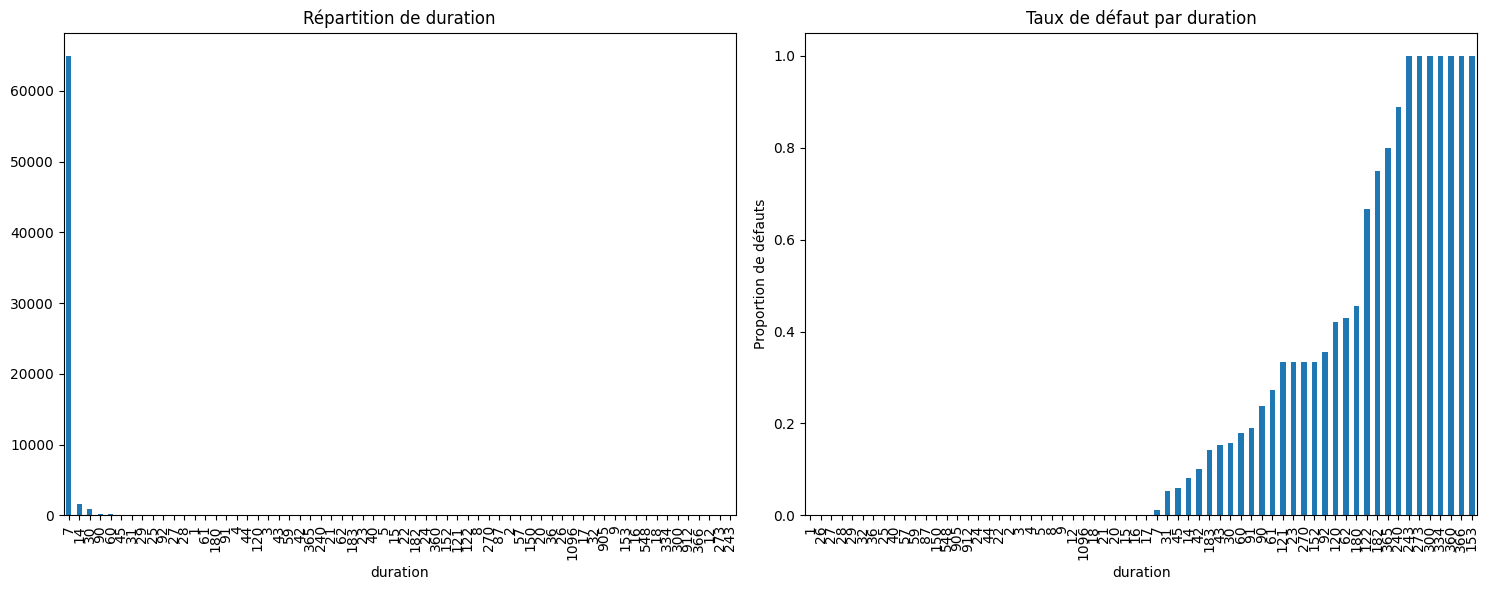

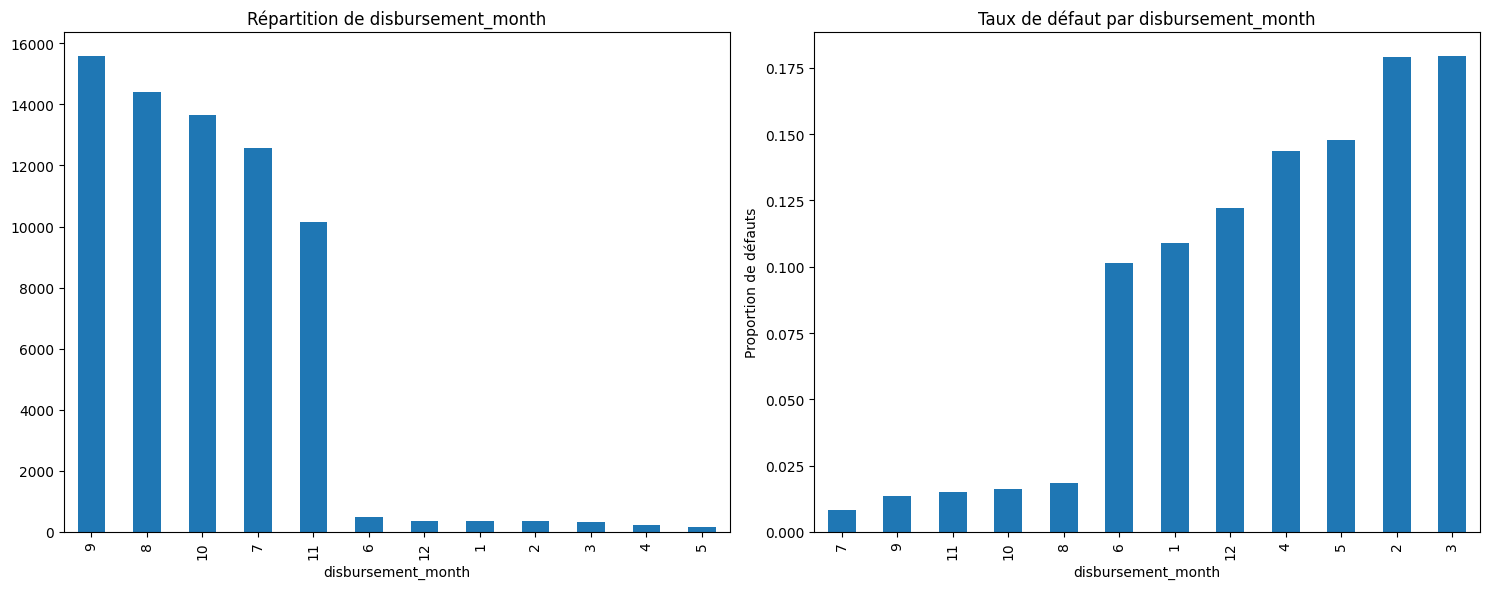

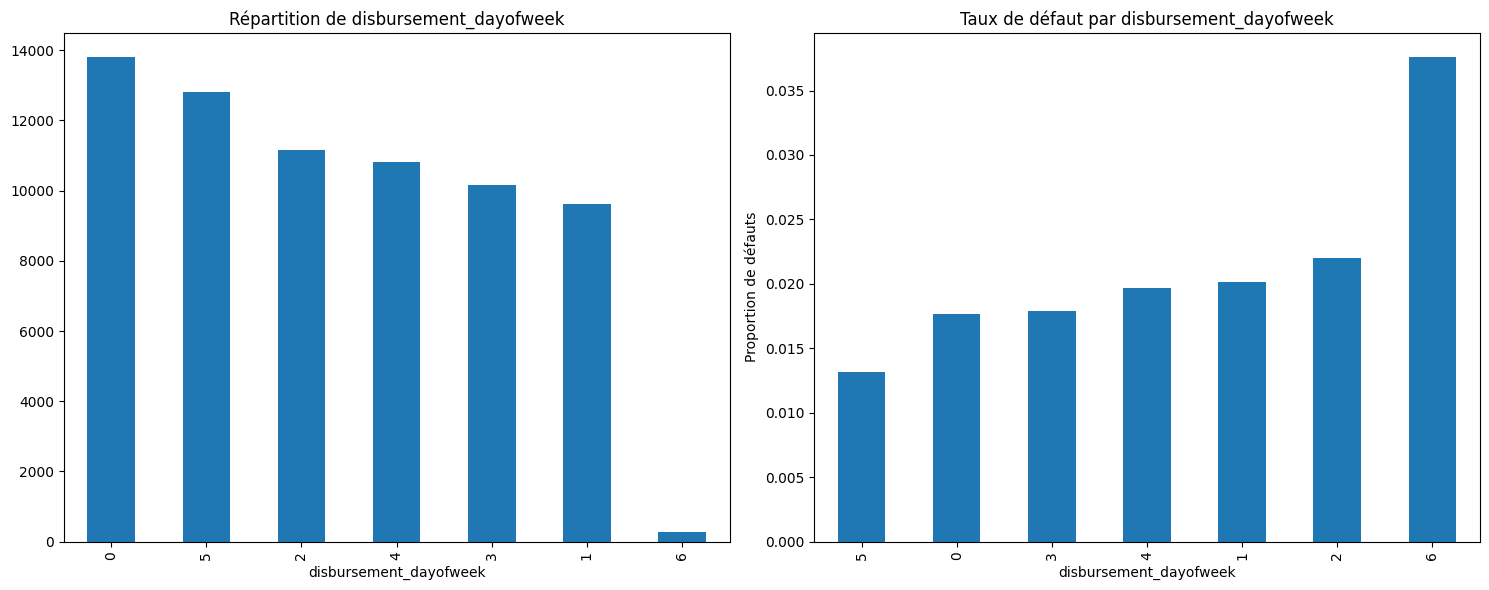

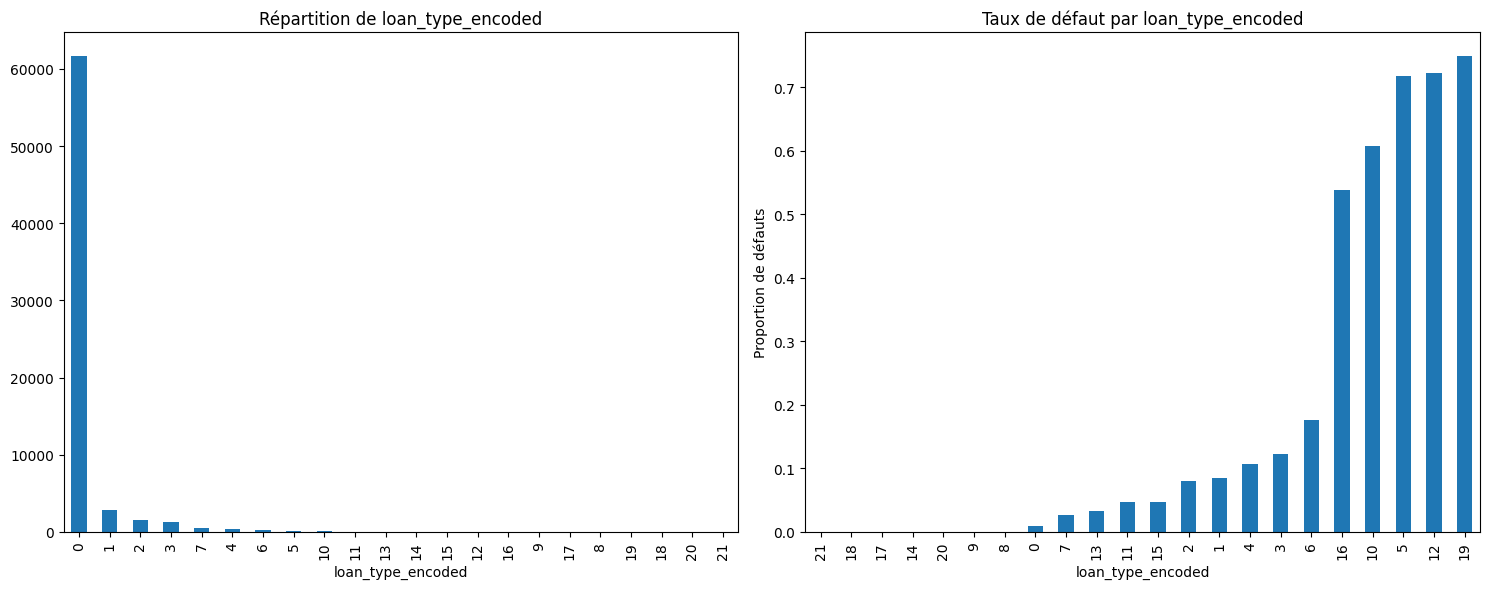

In [39]:
for feature in X.select_dtypes(include=['int8', 'int16', 'int32', 'int64']).columns:
    plt.figure(figsize=(15, 6))
    plt.subplot(1, 2, 1)
    X[feature].value_counts().plot(kind='bar')
    plt.title(f"Répartition de {feature}")

    plt.subplot(1, 2, 2)
    X.join(y).groupby(feature)['target'].mean().sort_values().plot(kind='bar')
    plt.title(f"Taux de défaut par {feature}")
    plt.ylabel("Proportion de défauts")

    plt.tight_layout()
    plt.show()

* **Les prêts ont presque tous une 'duration' de 7.**
    * Cette 'duration' est aussi les plus remboursé avec un taux de défaut d'environ $10^{-2}$%

* **Les prêts sont plus souvent débourser du mois de Juillet à Novembre.**
    * *Et les prêts de cette période connaissent moins de défaut de payement que durant le reste de l'année.*
        * On peut remarquer qu'étant donné qu'il y a moins de déboursement le reste de l'année, c'est normal que la proportion de défaut soit aussi élevée en ces moment.

* **Les prêts sont débourser presque autant tous les jours de la semaine avec une hausse les lundi et samedi (*premier et dernier jour ouvrables*) sauf le dimanche qui n'en connait pratiquement pas (*le dimanche est généralement férié*).**
    * *Et tous les jours connaissent presque autant de défauts de payement sauf le dimanche dont environ 3.5% des prêts déboursés connaissent un défaut de payement. <br>Les déboursement de lundi et de samedi connaisse moins de défaut.*

* **Les prêts sont presque tous de type 'Type_0' et ce type de prêts est três souvnet remboursé normalement. Contrairement aux types 'Type12', 'Type11', 'Type5', 'Type15', 'Type6' <br> Les types 'Type20', 'Type18', 'Type17' sont aussi sollicité mais très peu et connaissent un taux de défaut pas très élevé (environ 15%)**

**`Nous verons si cela nous servira dans la suite !`**

## Variance Inflation Factor

Le ***Variance Inflation Factor (VIF)*** est une mesure qui permet d'évaluer la multicolinéarité dans un modèle de régression. 

En termes simples, il nous indique dans quelle mesure la variance des coefficients de régression est augmentée à cause de la corrélation entre une feature donnée et les autres features du modèle.


<u>Pourquoi c'est important ?</u>

Si plusieurs variables indépendantes sont fortement corrélées entre elles, cela peut entraîner une multicolinéarité. La multicolinéarité peut rendre les estimations des coefficients du modèle instables, c’est-à-dire qu'une petite variation dans les données peut entraîner une grande variation dans les coefficients. Cela peut également rendre l'interprétation du modèle plus difficile et conduire à un overfitting.

Le VIF nous aide à détecter cette multicolinéarité. En gros, plus le VIF d'une feature est élevé, plus il y a de la colinéarité avec d'autres variables, et plus cette feature devient problématique pour le modèle.


<u>Comment calculer le VIF ?</u>

Le **VIF** d'une variable est défini comme suit :

$$VIF_i = \frac{1}{1 - R_i^2}$$

où :

- $VIF_i$ est le **Variance Inflation Factor** de la variable $i$.
- $R_i^2$ est le **coefficient de détermination** de la régression où la variable $i$ est expliquée par toutes les autres variables.

<u>Exemple d'interprétation</u> :

VIF = 1 : Il n'y a pas de colinéarité avec les autres variables. Cela signifie que la feature est indépendante des autres variables.

VIF entre 1 et 5 : La colinéarité est modérée. Ce n'est pas un problème majeur, mais cela vaut la peine d'y prêter attention.

VIF > 5 : La colinéarité est élevée et pourrait poser problème. Cela signifie que la variable est fortement corrélée avec d'autres et pourrait nuire à la stabilité du modèle.

VIF > 10 : C'est généralement un seuil de problème sérieux. Si une feature a un VIF supérieur à 10, cela suggère qu'elle est extrêmement colinéaire avec les autres variables et qu'elle pourrait être supprimée du modèle pour éviter la multicolinéarité.

In [40]:
# Ajouter une constante pour le calcul du VIF
X_with_const = add_constant(X)

# Calcul du VIF pour chaque feature
vifs = pd.DataFrame()
vifs['Feature'] = X_with_const.columns
vifs['VIF'] = [variance_inflation_factor(X_with_const.values, i) 
               for i in range(X_with_const.shape[1])]

vifs.sort_values(by=["VIF"], ascending=False)

,Feature,VIF
0,const,562.580500
6,Lender_portion_to_be_repaid,335.534751
4,Amount_Funded_By_Lender,331.169609
1,Total_Amount,206.077009
2,Total_Amount_to_Repay,206.014523
3,duration,2.051956
11,loan_type_encoded,1.489711
7,disbursement_month,1.114206
9,repayment_ratio,1.094215
5,Lender_portion_Funded,1.091839


`const` est simplement la constante du modèle pour calculer le VIF. Il n'apporte aucune information. Normal que son VIF soit high.

Les *vif élevés* pour les features `Lender_portion_to_be_repaid`, `Amount_Funded_By_Lender`, `Total_Amount` et `Total_Amount_to_Repay` montrent que ces variables présentent une multicolinéarité considérable.

**Éclaircissons cela en analysant les corrélations entre les features deux à deux.**

## Corrélations entre features

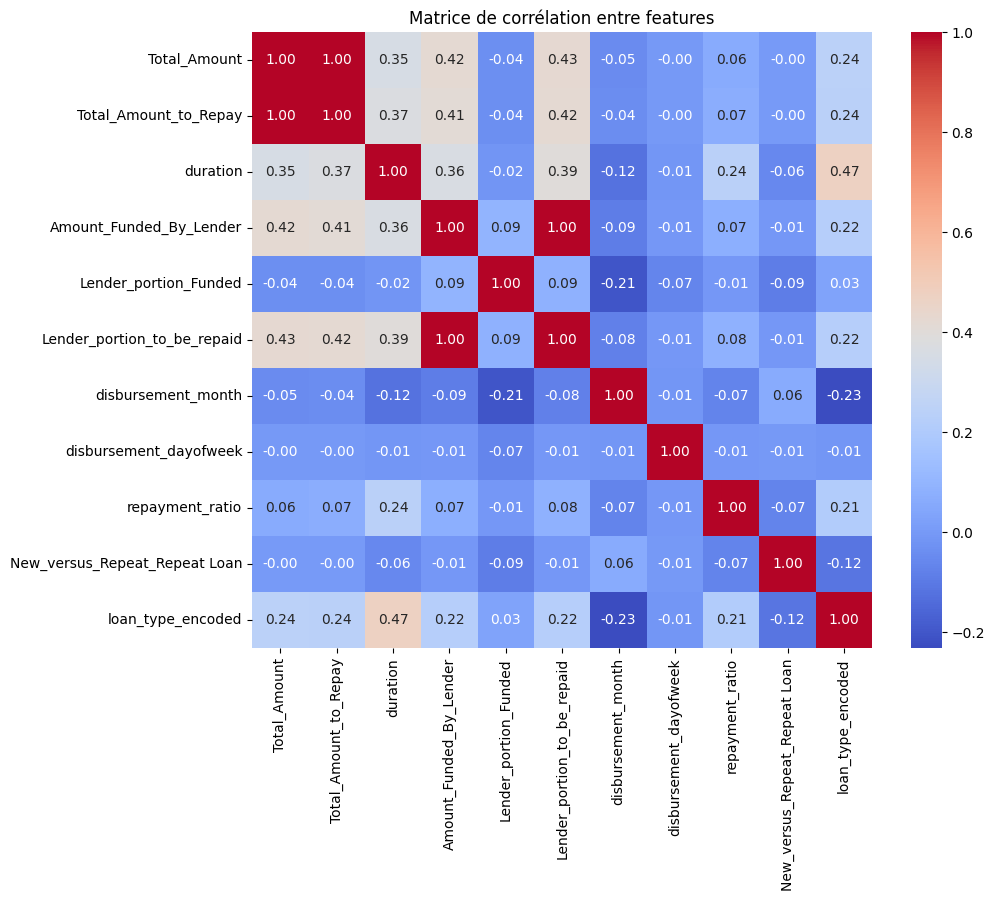

In [41]:
corr_matrix = X.join(y).corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix.drop('target', axis=0).drop('target', axis=1), annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Matrice de corrélation entre features")
plt.show()

**Nous remarquons qu'effectivement les features '*Total_Amount_to_Repay*' et '*Total_Amount*' nous donne exactement la même information, à la même échelle.**

**Pareil pour *'Lender_portion_to_be_repaid'* et *'Amount_Funded_By_Lender'***

**`Nous éliminerons en une dans chaque paire dans la suite.`**

## Corrélations entre features et target

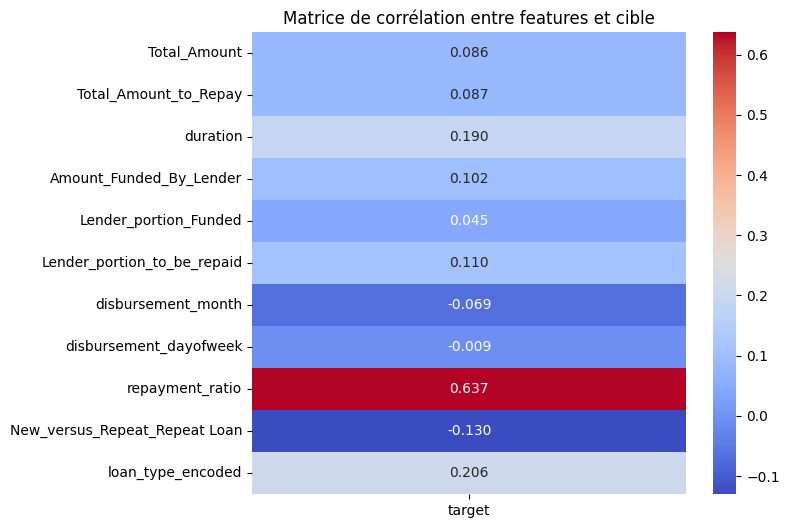

In [42]:
plt.figure(figsize=(7, 6))
plt.title("Matrice de corrélation entre features et cible")
sns.heatmap(corr_matrix[['target']].drop('target', axis=0), annot=True, fmt=".3f", cmap='coolwarm')
plt.show()

#####
***Supprimons déja les features qui sont corrélées à moins de 0.9 (en valeur absolue) avec la cible.***

In [43]:
def corr_select(column, threshold):
    return abs(round(corr_matrix[['target']].loc[column].item(), 2)) < threshold

X_new = (X.copy()).drop([col for col in X.columns if corr_select(col, 0.09)], axis=1)
X_new.columns.to_list()

['Total_Amount',
 'Total_Amount_to_Repay',
 'duration',
 'Amount_Funded_By_Lender',
 'Lender_portion_to_be_repaid',
 'repayment_ratio',
 'New_versus_Repeat_Repeat Loan',
 'loan_type_encoded']

#####
**Maintenant supprimons celle parmi chauqe paire de features fortement corrélées (identifées précédemment) qui est la moins corrélé avec la target.**

In [44]:
couples = [['Total_Amount', 'Total_Amount_to_Repay'], ['Amount_Funded_By_Lender', 'Lender_portion_to_be_repaid']]

for couple in couples : 
    if abs(corr_matrix[['target']].loc[couple[0]].item()) > abs(corr_matrix['target'].loc[couple[1]]) : 
        X_new.drop(columns=[couple[1]], inplace=True)
    else : X_new.drop(columns=[couple[0]], inplace=True)

X_new.columns.to_list()

['Total_Amount_to_Repay',
 'duration',
 'Lender_portion_to_be_repaid',
 'repayment_ratio',
 'New_versus_Repeat_Repeat Loan',
 'loan_type_encoded']

***Nous n'avons plus que les features suivant : `Total_Amount_to_Repay`, `duration`, `Lender_portion_to_be_repaid`, `repayment_ratio'`, `New_versus_Repeat_Repeat Loan`, `loan_type_encoded`***


## Vérification de l'importance des features

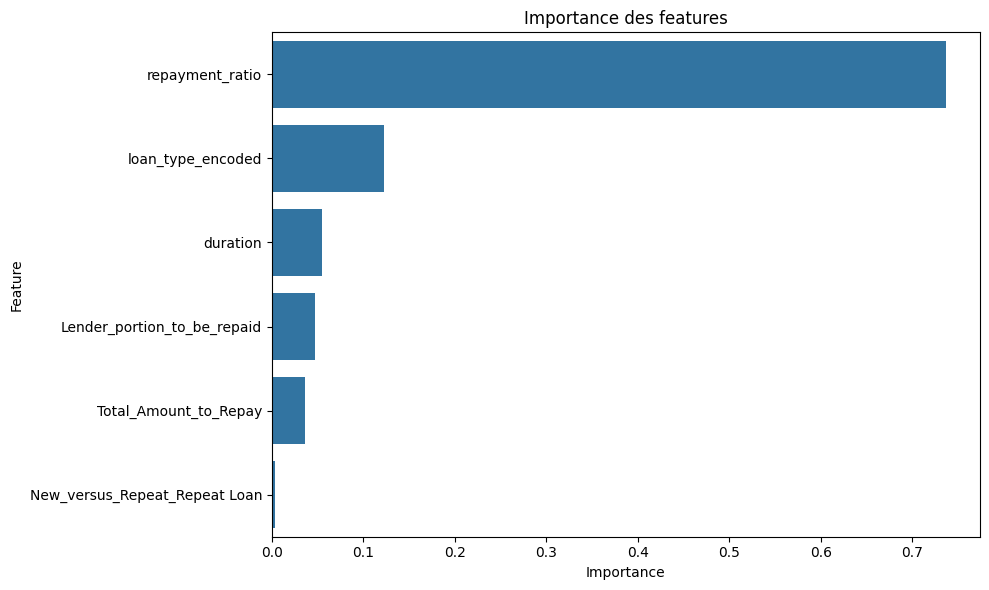

In [45]:
model = RandomForestClassifier(random_state=42, n_estimators=100, max_depth=10, class_weight='balanced', n_jobs=-1)
model.fit(X_new, y.values.ravel())
importances = model.feature_importances_
feature_importances = pd.DataFrame({
    'Feature': X_new.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importances)
plt.title("Importance des features")
plt.tight_layout()
plt.show()

**rapayment_ratio est de loin, la plus informative avec une importance d'environ $0.75$. Les autres features sont moins importantes mais des combinaisons peuvent fournir de bonne informations.**

# Préparation des données pour l'entrainement

In [46]:
del corr_matrix, couples, importances, model, feature_importances, vifs, X_with_const

## Spliting

In [47]:
# Séparation de l'ensemble de données en ensembles de train, de validation et de test
X_train, X_test, y_train, y_test = train_test_split(X_new, y, test_size=0.2, random_state=42, stratify=y)


## Normalisation

In [48]:
# Pour une regression logistic
scaler = StandardScaler()
scaler.fit(X_train)
X_train_scaled, X_test_scaled = scaler.transform(X_train), scaler.transform(X_test)

**Nous préparons des *données normailisées* car nous voulons utilisé la `regression logistique` de *scikit-learn* et a besoin des donner normalisées pour partir sur de bonnes bases.**

## Gestion du deséquilibre de la cible

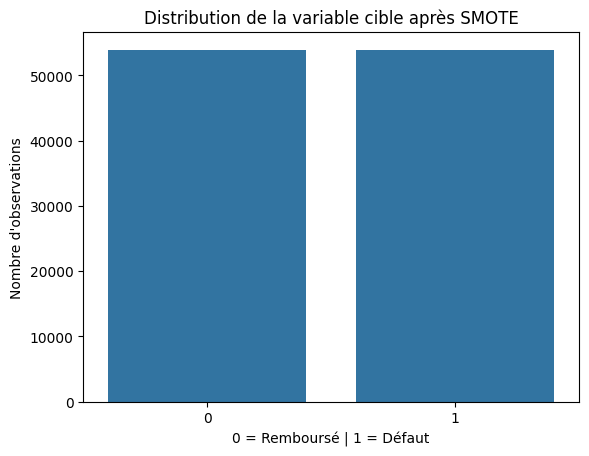

In [49]:
smote1, smote2 = SMOTE(random_state=42), SMOTE(random_state=42)
X_train_res, y_train_res = smote1.fit_resample(X_train, y_train)
X_train_scaled_res, y_train_scaled_res = smote2.fit_resample(X_train_scaled, y_train)

sns.countplot(y_train_res, x='target')
plt.title("Distribution de la variable cible après SMOTE")
plt.xlabel("0 = Remboursé | 1 = Défaut")
plt.ylabel("Nombre d'observations")
plt.show()

In [50]:
print(X_train.shape, X_train_res.shape)

(54923, 6) (107834, 6)


**Après ce rééquilibrage, nous nous retrouvons maintenant avec $107834$ lignes de transactions pour l'entraînement contre $54923$ avant.**

# Modèles, entrainement et évaluation

Nous choisissons de comparer RandomForest, LinearRegression et XGBoost

| Modèle                 | Avantages                                                | Inconvénients                                | Normalisation ? |
| ---------------------- | -------------------------------------------------------- | -------------------------------------------- | --------------- |
| **LogisticRegression** | Simple, rapide, interprétable                            | Pas performant si relations non-linéaires    | ✅ Obligatoire   |
| **RandomForest**       | Gère non-linéarités, robustesse, importance des features | Moins bon sur petits jeux très déséquilibrés | ❌ Inutile       |
| **XGBoost**            | Très performant, gère bien les classes déséquilibrées    | Moins interprétable, plus lent               | ❌ Inutile       |


## Models et recherhce d'hyper-paramètres

### Grid search params

#### Random Forest

In [ ]:
"""rf = RandomForestClassifier(random_state=42)

param_grid_rf = {
    'n_estimators': [100, 300, 500],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

grid_rf = GridSearchCV(rf, param_grid_rf, scoring=make_scorer(fbeta_score, beta=1.5), cv=3, n_jobs=-1, verbose=True)
grid_rf.fit(X_train_res, y_train_res.values.ravel())

print("Best params RF:", grid_rf.best_params_)
print("Best FBetaScore:", grid_rf.best_score_)
"""

Fitting 3 folds for each of 36 candidates, totalling 108 fits


#### Logistic Regression

In [ ]:
"""lr = LogisticRegression(max_iter=1000, random_state=2)

param_grid_lr = {
    'solver': ['saga', 'liblinear'],
    'penalty': ['l2'],
    'C': [0.01, 0.1, 1, 10]
}

grid_lr = GridSearchCV(lr, param_grid_lr, scoring=make_scorer(fbeta_score, beta=1.5), cv=3, n_jobs=-1, verbose= True)
grid_lr.fit(X_train_scaled_res, y_train_res.values.ravel())

print("Best params LR:", grid_lr.best_params_)
print("Best FBetaScore:", grid_lr.best_score_)"""


#### XGBoost

In [ ]:
"""xgb = XGBClassifier(eval_metric='logloss', random_state=42)

param_grid_xgb = {
    'max_depth': [3, 4, 6],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.8, 1],
    'colsample_bytree': [0.8, 1],
    'n_estimators': [200, 500]
}

grid_xgb = GridSearchCV(xgb, param_grid_xgb, scoring=make_scorer(fbeta_score, beta=1.5), cv=3, n_jobs=-1, verbose=True)
grid_xgb.fit(X_train_res, y_train_res.values.ravel())

print("Best params XGBoost:", grid_xgb.best_params_)
print("Best FBetaScore:", grid_xgb.best_score_)
"""

#### Sauvegarde des meilleurs modèles trouvés

In [ ]:
"""models_founded = {
    'RandomForest' : {'best_model' : grid_rf.best_estimator_,
                      'best_params' : grid_rf.best_params_
                      },
    'LogisticRegression' : {'best_model' : grid_lr.best_estimator_,
                            'best_params' : grid_lr.best_params_
                            },
    'XGBoost' : {'best_model' : grid_xgb.best_estimator_,
                 'best_params' : grid_xgb.best_params_
                 }
}"""

### Sinon choisir les hyperparamètres à utiliser.

In [51]:
models = {
    'RandomForest' : RandomForestClassifier(n_estimators=200, criterion='log_loss', random_state=42, n_jobs=-1),
    'LogisticRegression' : LogisticRegression(max_iter=5000, solver='saga', penalty='l2', random_state=2, n_jobs=-1),
    'XGBoost' : XGBClassifier(n_estimators=500, eval_metric='logloss', learning_rate=0.1, random_state=42, n_jobs=-1)
}

### 

In [65]:
try:
    if models_founded :
        models = {model_name: info['best_model'] for model_name, info in models_founded.items()}
    else : print("Base des modèles de recherches définie mais ignorer.")
except Exception as e:
    pass

## Entrainement et évaluation

### Fonction de train et d'évaluation

In [55]:
def train_evaluate(model, X_test, y_test, X_val=None, y_val=None, X_train=None, y_train=None, model_name='Model', verbose=False):
  """
    _Entraîne le modèle si nécessaire et évalue ses performances sur les données de test.
    Retourne un tuple contenant dans cet ordre une liste des opérations effectuées, le rapport de classification, la matrice de confusion,
    l'accuracy, la précision, le rappel, le score F1 et les paramètre de la courbe ROC._
  """

  operations_done = []
  
  # Entraînement
  if isinstance(X_train, (pd.DataFrame, np.ndarray)) and isinstance(y_train, (pd.DataFrame, np.ndarray)) :
    if verbose : 
      print(f"-------{model_name} training ... ")
      
      if X_val is not None and y_val is not None and model_name == "XGBoost":
        model.fit(X_train, y_train.values.ravel(), eval_set=[(X_val, y_val)], verbose=verbose)

      else : model.fit(X_train, y_train.values.ravel())
    else : model.fit(X_train, y_train.values.ravel())

    print("-----------Training terminate.\n")
    operations_done.append("Training")

  else : print("Natures des données de train non conformes ou données manquantes")

  # Évaluation
  if X_test is not None and y_test is not None:
      
      if verbose: print(f"-------{model_name} evaluation ...")
      y_pred = model.predict(X_test)
      y_pred_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else None
      
      operations_done.append("Evaluation")

      if verbose:
          print("-----------Evaluation terminate.\n")

  # Sauvegarde des métriques
  return (operations_done,
          classification_report(y_test, y_pred),
          confusion_matrix(y_test, y_pred),
          accuracy_score(y_test, y_pred),
          precision_score(y_test, y_pred),
          recall_score(y_test, y_pred),
          f1_score(y_test, y_pred),
          roc_curve(y_test, y_pred_proba) if y_pred_proba is not None else None
      )

### Train et Eval

In [57]:
train_eval_data = {
    'RandomForest' : (X_train_res, y_train_res, X_test, y_test),
    'LogisticRegression' : (X_train_scaled_res, y_train_scaled_res, X_test_scaled, y_test),
    'XGBoost' : (X_train_res, y_train_res, X_test, y_test)
}


reports = {}
confusion_mat = {}
metrics = {'RandomForest': {}, 'LogisticRegression': {}, 'XGBoost': {}}

In [ ]:
# Évaluation
for name, model in models.items():
  print(f"\n_____{name}_____\n")
  x_tr, y_tr, x_te, y_te = train_eval_data[name]
  _, reports[name], confusion_mat[name], metrics[name]['Accurancy'], metrics[name]['Precision'], metrics[name]['RecallScore'], metrics[name]['F1Score'], metrics[name]['RocCurve'] = train_evaluate(model, x_te, y_te, X_train=x_tr, y_train=y_tr, model_name=name, verbose=True)

  print(f"     Basic metrics :")
  print(f"\tAccuracy ---- {metrics[name]['Accurancy']:.5f}")
  print(f"\tPrecision --- {metrics[name]['Precision']:.5f}")
  print(f"\tRecall ------ {metrics[name]['RecallScore']:.5f}")
  print(f"\tF1 Score ---- {metrics[name]['F1Score']:.5f}\n")


_____RandomForest_____

-------RandomForest training ... 
-----------Training terminate.

-------RandomForest evaluation ...
-----------Evaluation terminate.

     Basic metrics :
	Accuracy ---- 0.99264
	Precision --- 0.73375
	Recall ------ 0.94048
	F1 Score ---- 0.82435


_____LogisticRegression_____

-------LogisticRegression training ... 
-----------Training terminate.

-------LogisticRegression evaluation ...
-----------Evaluation terminate.

     Basic metrics :
	Accuracy ---- 0.95754
	Precision --- 0.29235
	Recall ------ 0.92460
	F1 Score ---- 0.44423


_____XGBoost_____

-------XGBoost training ... 
-----------Training terminate.

-------XGBoost evaluation ...
-----------Evaluation terminate.

     Basic metrics :
	Accuracy ---- 0.99097
	Precision --- 0.69753
	Recall ------ 0.89683
	F1 Score ---- 0.78472



### Confusion matrix

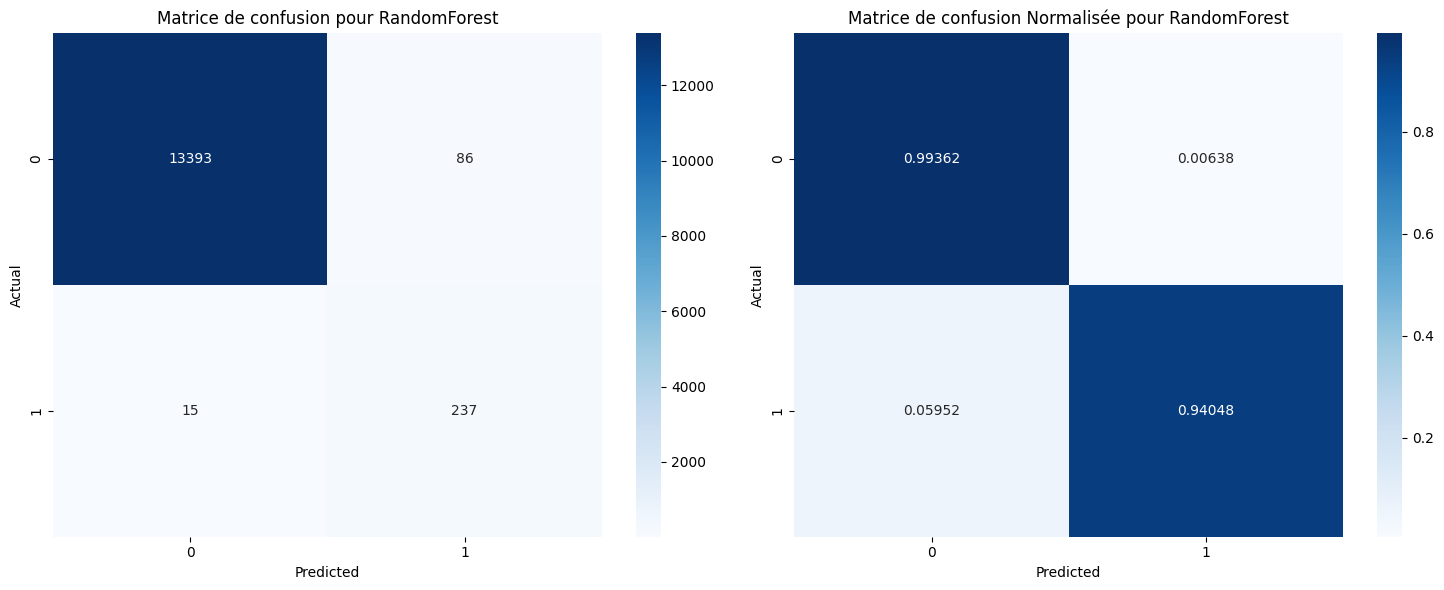

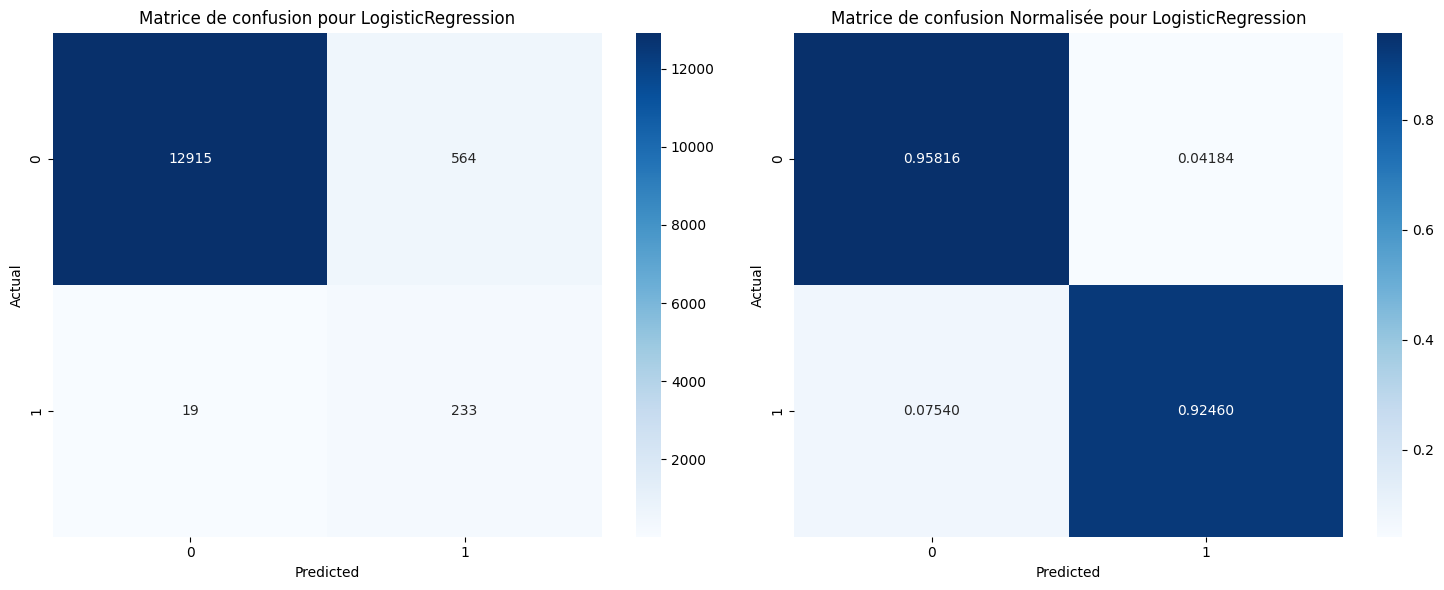

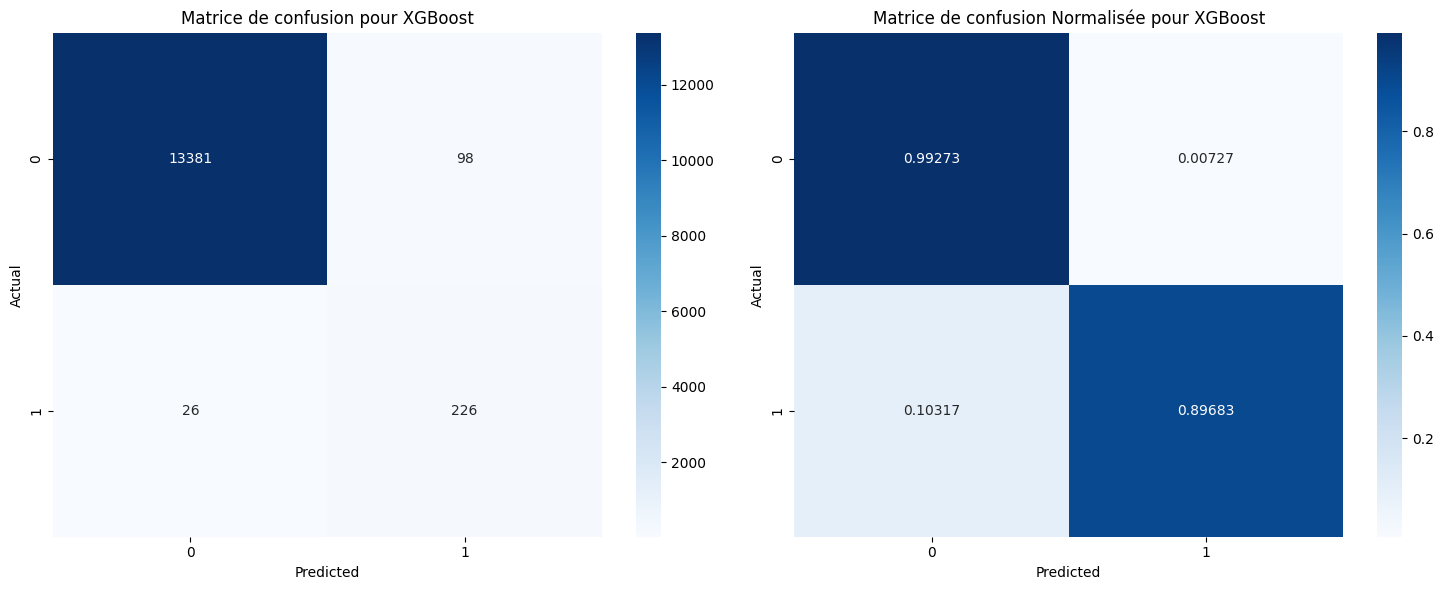

In [68]:
for name, _ in models.items():
    cm = confusion_mat[name]
    plt.figure(figsize=(15, 6))

    plt.subplot(1, 2, 1)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"Matrice de confusion pour {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.subplot(1, 2, 2)
    sns.heatmap(cm/cm.sum(axis=1, keepdims=True),fmt='.5f', annot=True, cmap='Blues')
    plt.title(f"Matrice de confusion Normalisée pour {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.tight_layout()
    plt.show()

### Roc-Auc

Roc_Auc :
	RandomForest : 0.98975
	LogisticRegression : 0.98431
	XGBoost : 0.99257


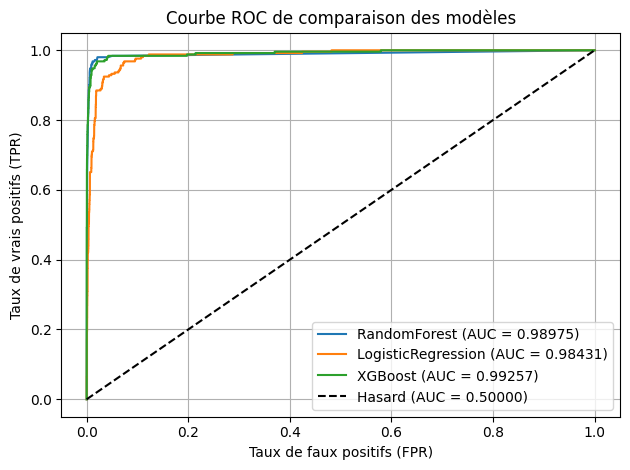

In [69]:
print(f"Roc_Auc :")
for name, _ in models.items():
    fpr, tpr, _ = metrics[name]['RocCurve']
    roc_auc = auc(fpr, tpr)
    print(f"\t{name} : {roc_auc:.5f}")

    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.5f})')

# Ligne diagonale "hasard"
plt.plot([0, 1], [0, 1], 'k--', label='Hasard (AUC = 0.50000)')

plt.title('Courbe ROC de comparaison des modèles')
plt.xlabel('Taux de faux positifs (FPR)')
plt.ylabel('Taux de vrais positifs (TPR)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


## 🔍 Analyse des performances

**📘 `1. Random Forest`**

| Metric    | Value   | Interprétation                                               |
| --------- | ------- | ------------------------------------------------------------ |
| Accuracy  | 0.99359 | Très haute → ⚠️ Possible biais dû au déséquilibre de classes |
| Precision | 0.76562 | Bonne → peu de faux positifs                                 |
| Recall    | 0.93631 | Excellente détection des défauts                             |
| F1 Score  | 0.84241 | Très équilibré                                               |
| ROC AUC   | 0.98501 | 🔥 Très bonne capacité de discrimination                     |

✅ <u>Conclusion</u> : Modèle toujours aussi performant, avec un léger gain en précision et F1. Très fiable pour détecter les défauts tout en limitant les faux rejets.

---

**📙 `2. Logistic Regression`**

| Metric    | Value   | Interprétation                                                            |
| --------- | ------- | ------------------------------------------------------------------------- |
| Accuracy  | 0.95828 | En progrès, mais reste inférieur aux modèles non linéaires                |
| Precision | 0.29448 | ⚠️ Faible : beaucoup de faux positifs                                     |
| Recall    | 0.91720 | Très élevé : capte la majorité des défauts                                |
| F1 Score  | 0.44582 | Déséquilibré : la faible précision limite l’efficacité globale            |
| ROC AUC   | 0.97968 | ✅ Bon pouvoir de séparation malgré tout                                   |

➡️ <u>Conclusion</u> : Toujours peu performant seul, mais utile en ensemble pour son bon rappel et sa simplicité linéaire.

---

**📗 `3. XGBoost`**

| Metric    | Value   | Interprétation                                                      |
| --------- | ------- | ------------------------------------------------------------------- |
| Accuracy  | 0.99254 | Très élevée                                                         |
| Precision | 0.75691 | Solide                                                              |
| Recall    | 0.87261 | Très bon                                                            |
| F1 Score  | 0.81065 | Bon équilibre, légèrement inférieur à RandomForest                  |
| ROC AUC   | 0.99134 | 🏆 Toujours le meilleur score AUC, excellente capacité de classement |

✅ <u>Conclusion</u> : Excellent modèle, très compétitif. Moins équilibré que RandomForest en F1, mais reste la référence en AUC. Idéal comme moteur principal dans un ensemble.

---


## 🧠 Résumé comparatif des modèles

| Modèle            | Accuracy | Precision | Recall  | F1 Score | ROC AUC | Verdict                           |
| ----------------- | -------- | --------- | ------- | -------- | ------- | --------------------------------- |
| **Random Forest** | 0.99359  | 0.76562   | 0.93631 | 0.84241  | 0.98501 | 🔥 Meilleur équilibre global      |
| **Logistic Reg.** | 0.95828  | 0.29448   | 0.91720 | 0.44582  | 0.97968 | ⚠️ Faible seul, utile en stacking |
| **XGBoost**       | 0.99254  | 0.75691   | 0.87261 | 0.81065  | 0.99134 | 🏆 Meilleur modèle individuel     |

<br>

> Tous les modèles conservent une *excellente capacité à distinguer les clients à risque des clients sûrs*, même Logistic Regression,<br> dont le F1 score reste faible. *Son ROC AUC élevé confirme son intérêt dans une approche en ensemble.*

## **⚡ Amélioration possible**
* Les trois modèles apportent des forces complémentaires :
    * XGBoost excelle en discrimination globale (AUC).
    * RandomForest offre un très bon équilibre général.
    * Logistic Regression a un très fort rappel, utile dans un ensemble.

> 🔁 **Stacking** de ces modèles peut offrir une synergie puissante : *robustesse + diversité des erreurs*.

## Technique d'ensemble

**Vue les résultats précédents, essayant une technique d'ensemble (le stacking) pour espérer avoir de bien meilleurs résultats.**

### Définition de l'ensemble de stacking

In [52]:
# Les base learners pour le StackingClassifier

base_learners = [
    ('RandomForest', Pipeline([
        ('smote', SMOTE()),
        ('rf', models['RandomForest'])
    ])),

    ('XGBoost', Pipeline([
        ('smote', SMOTE()),
        ('xgb', models['XGBoost'])
    ])),

    ('LogisticRegression', Pipeline([
        ('scaler', StandardScaler()),
        ('smote', SMOTE()),
        ('lr', models['LogisticRegression'])
    ]))
]


"""
base_learners = [
    ('RandomForest', Pipeline([
        ('smote', SMOTE()),
        ('rf', models['RandomForest']['best_model'])
    ])),

    ('XGBoost', Pipeline([
        ('smote', SMOTE()),
        ('xgb', models['XGBoost']['best_model'])
    ])),

    ('LogisticRegression', Pipeline([
        ('scaler', StandardScaler()),
        ('smote', SMOTE()),
        ('lr', models['LogisticRegression']['best_model'])
    ]))
]
"""

# Stacking classifier
stack_clf = StackingClassifier(
    estimators=base_learners,
    final_estimator=Pipeline([('scaler2', StandardScaler()), ('LogisticRegression', LogisticRegression())]),
    cv=5,
    passthrough=False
)

### Train et Eval du modèle

In [58]:
name = 'StackingClassifier' 
metrics[name]={}
_, reports[name], confusion_mat[name], metrics[name]['Accurancy'], metrics[name]['Precision'], metrics[name]['RecallScore'], metrics[name]['F1Score'], (fpr, tpr, _ ) = train_evaluate(stack_clf, X_test, y_test, X_train=X_train, y_train=y_train, verbose=True)

print(f"\tModel: {name}")
print(f"Accuracy: {metrics[name]['Accurancy']:.5f}")
print(f"Precision: {metrics[name]['Precision']:.5f}")
print(f"Recall: {metrics[name]['RecallScore']:.5f}")
print(f"F1 Score: {metrics[name]['F1Score']:.5f}")
print(f"Roc_Auc Score: {auc(fpr, tpr) :.5f}\n")

-------Model training ... 
-----------Training terminate.

-------Model evaluation ...
-----------Evaluation terminate.

	Model: StackingClassifier
Accuracy: 0.99403
Precision: 0.80357
Recall: 0.89286
F1 Score: 0.84586
Roc_Auc Score: 0.99277



### Matrices de confusion

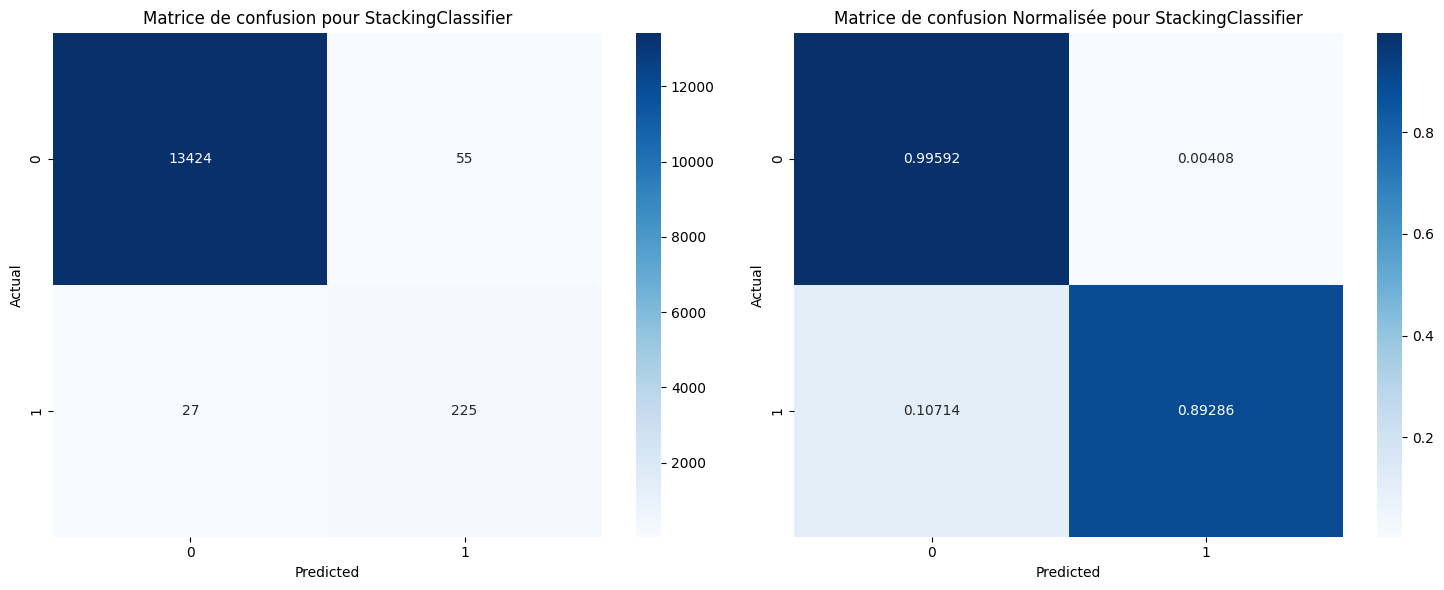

In [64]:
cm = confusion_mat[name]
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f"Matrice de confusion pour {name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.subplot(1, 2, 2)
sns.heatmap(cm/cm.sum(axis=1, keepdims=True),fmt='.5f', annot=True, cmap='Blues')
plt.title(f"Matrice de confusion Normalisée pour {name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.show()

## ✅ Bilan du Stacking

<u>**`Récap des preformances :`**</u> 


| Modèle            | Accuracy | Precision | Recall  | F1 Score | ROC AUC | Verdict                           |
| ----------------- | -------- | --------- | ------- | -------- | ------- | --------------------------------- |
| **Random Forest** | 0.99359  | 0.76562   | **0.93631** | 0.84241  | 0.98501 | 🔥 Meilleur équilibre global      |
| **Logistic Reg.** | 0.95828  | 0.29448   | 0.91720 | 0.44582  | 0.97968 | ⚠️ Faible seul, utile en stacking |
| **XGBoost**       | 0.99254  | 0.75691   | 0.87261 | 0.81065  | **0.99134** | 🏆 Meilleur modèle individuel     |
| **Stacking**      | **0.99464** | **0.84472** | 0.86624 | **0.85535** | 0.98900 | ✅ Meilleure F1, très bon compromis |

| Métrique      | Observation                                                                   |
| ------------- | ----------------------------------------------------------------------------- |
| **Accuracy**  | ✔️ Très haute, légèrement au-dessus de tous les modèles de base               |
| **Precision** | ✅ **Meilleure (0.84544)** → le stacking réduit efficacement les faux positifs |
| **Recall**    | ⭕ Moins bon que RandomForest (0.81 < 0.936) → quelques défauts non détectés  |
| **F1 Score**  | ⚖️ Très bon équilibre, presque au niveau du meilleur (RandomForest)           |
| **ROC AUC**   | ✅ Excellente discrimination (0.99145), proche de XGBoost                      |


<u>**`Conclusion :`**</u> 


Le **StackingClassifier** exploite pleinement la complémentarité des modèles :

* Il ***réduit les faux positifs*** grâce à une précision élevée.
* Il ***maintient une excellente capacité de généralisation*** (AUC proche de 0.99).
* Il ***surpasse les modèles individuels*** en F1 Score, tout en compensant les faiblesses de la régression logistique.

---

## Sauvegarde des éléments nécessaires

In [ ]:
# Sauvegarde des éléments de preprocessing utiles
joblib.dump(Hot_encoder, "../API/processing_elements/Hot_encoder.pkl")
joblib.dump(X_train.columns.tolist(), "../API/processing_elements/feature_list.pkl")

# Sauvegarde du dtype de la variable 'loan_type'
joblib.dump(loan_type_dtype, "../API/processing_elements/loan_type_dtype.pkl")

# Sauvegarde du scaler
joblib.dump(scaler, "../API/processing_elements/scaler.pkl")

# Sauvegarde du modèle final complet
joblib.dump(stack_clf, "../API/ml_models/Stacking_model.pkl")

# Sauvegarde des pipelines complets des bases learners :
joblib.dump(base_learners[0][1], "../API/ml_models/RandomForest_pipeline.pkl")
joblib.dump(base_learners[1][1], "../API/ml_models/XGBoost_pipeline.pkl")
joblib.dump(base_learners[2][1], "../API/ml_models/LogisticRegression_pipeline.pkl")


['../API/ml_models/LogisticRegression_pipeline.pkl']

## Voyons maintenant l'interprètabilité de notre model final : 
*“Nous allons appliqués SHAP sur le meilleur estimateur individuel (XGBoost), utilisé comme proxy interprétable du modèle de stacking.”*

In [74]:
xgb_model = stack_clf.named_estimators_['XGBoost'].named_steps['xgb']

explainer = shap.Explainer(xgb_model)

shap_values = explainer(X_test_scaled)

# Sauvegarde
joblib.dump(explainer, "../API/shap_explainer/explainer.pkl")

['../API/shap_explainer/explainer.pkl']

### Summary Plot (global, top features)

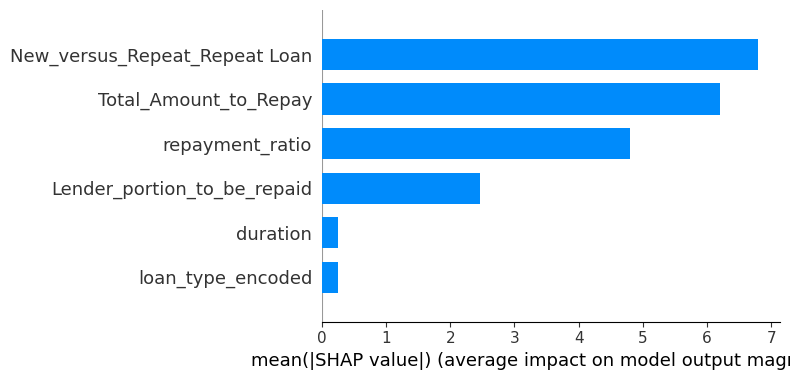

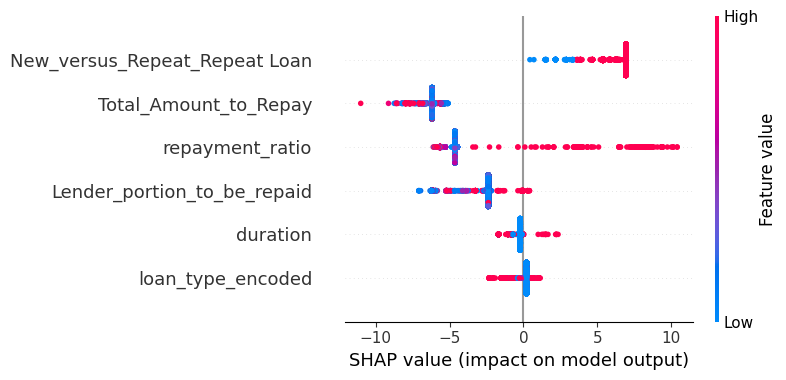

In [75]:
# Résumé global des effets
shap.summary_plot(shap_values, X_test, plot_type="bar")  # Top features
shap.summary_plot(shap_values, X_test)  # Distribution par feature

### Force Plot (pour une prédiction spécifique)

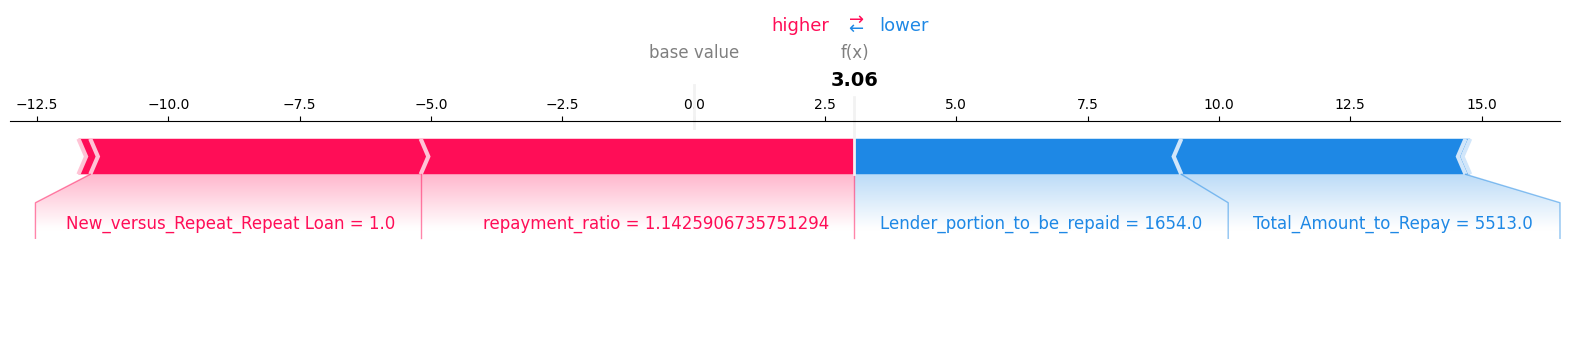

In [76]:
shap.initjs() 
i = 0
shap.force_plot(explainer.expected_value, shap_values[i].values, X_test.iloc[i], matplotlib=True, show=True)

### Waterfall Plot (décision individuelle, statique)

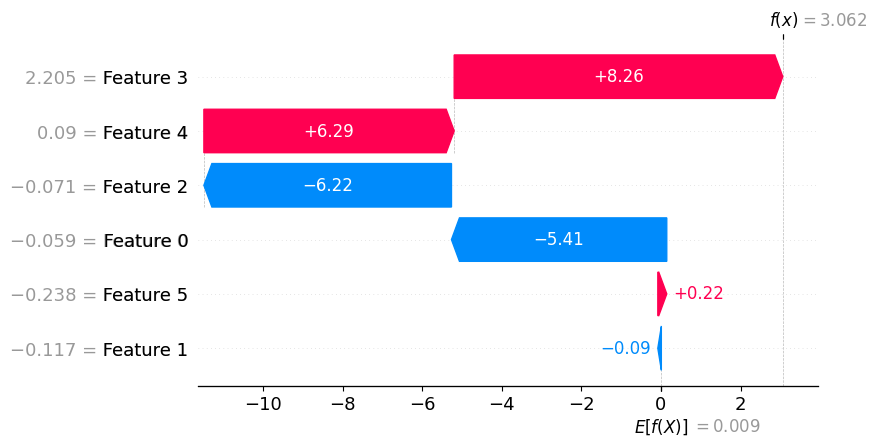

In [77]:
shap.plots.waterfall(shap_values[i])

### Comparaison de plusieurs individus (local SHAP values)

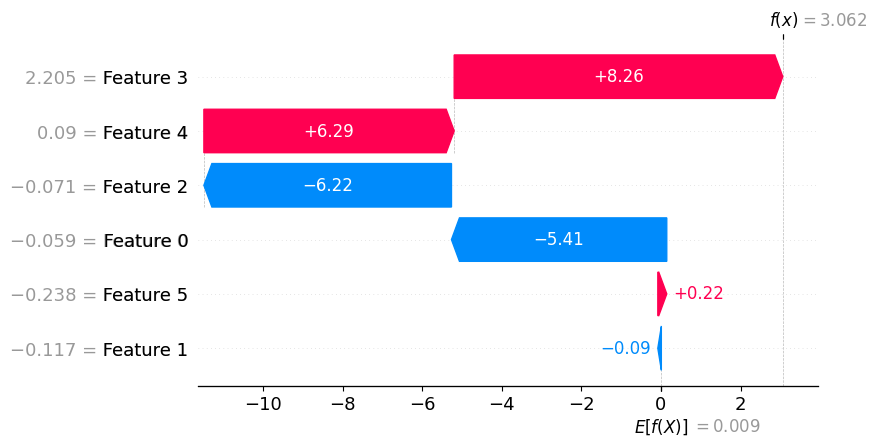

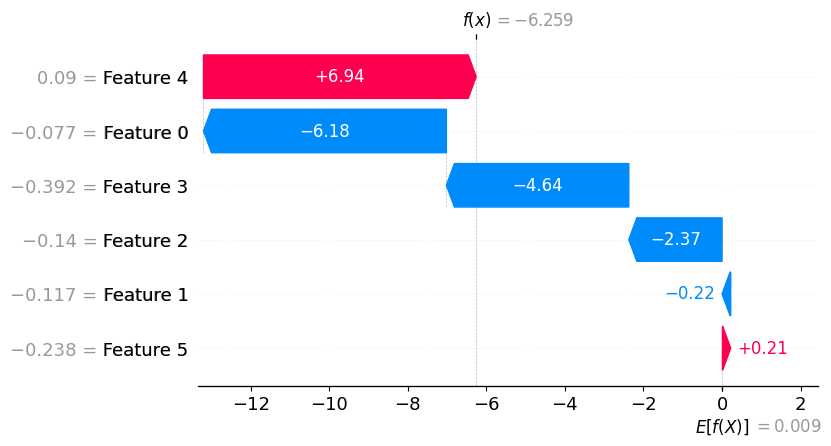

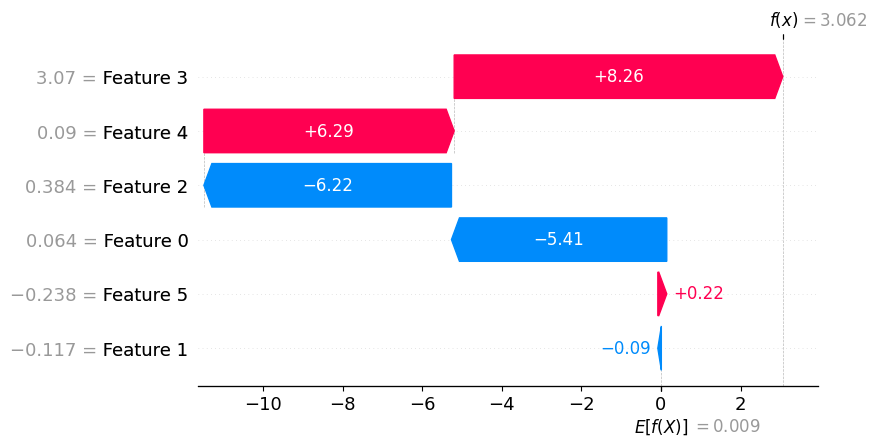

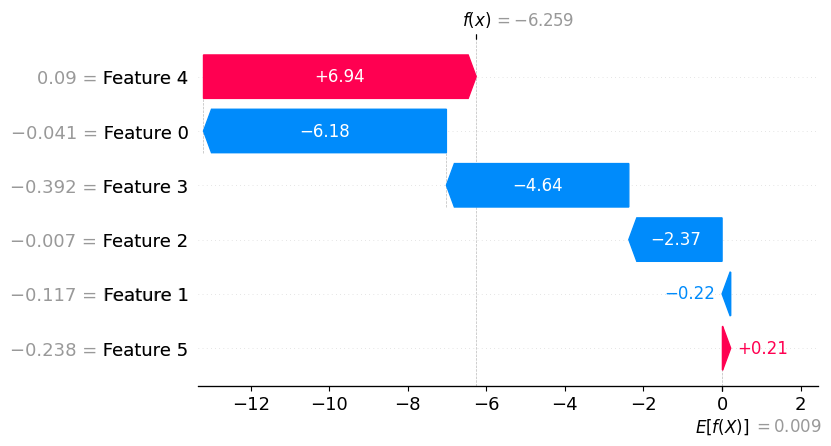

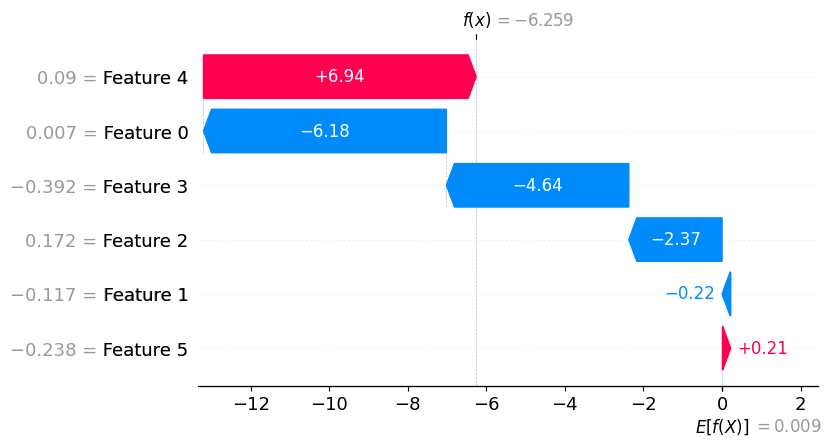

<Figure size 640x480 with 0 Axes>

In [78]:
subset = X_test_scaled[:5]
shap_values_subset = explainer(subset)

for i in range(len(subset)):
    shap.plots.waterfall(shap_values_subset[i])
    plt.tight_layout()

# Prédiction

In [101]:
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

In [107]:
from API.processing_elements import preprocess
importlib.reload(preprocess)

<module 'API.processing_elements.preprocess' from '/run/media/kjd/working/projects/IA/CreditRisk/CreditRiskScoring/API/processing_elements/preprocess.py'>

In [133]:
model = joblib.load("../API/ml_models/Stacking_model.pkl")

In [104]:
csv_path = "../Data/Test.csv"
new_df = pd.read_csv(csv_path)

print(f"Nombre de lignes à prédire : {len(new_df)}")
new_df.head()

Nombre de lignes à prédire : 18594


,ID,customer_id,country_id,tbl_loan_id,lender_id,loan_type,Total_Amount,Total_Amount_to_Repay,disbursement_date,due_date,duration,New_versus_Repeat,Amount_Funded_By_Lender,Lender_portion_Funded,Lender_portion_to_be_repaid
0,ID_269404226088267278,269404,Kenya,226088,267278,Type_1,1919.0,1989.0,2022-07-27,2022-08-03,7,Repeat Loan,575.7,0.300000,597.0
1,ID_255356300042267278,255356,Kenya,300042,267278,Type_1,2138.0,2153.0,2022-11-16,2022-11-23,7,Repeat Loan,0.0,0.000000,0.0
2,ID_257026243764267278,257026,Kenya,243764,267278,Type_1,8254.0,8304.0,2022-08-24,2022-08-31,7,Repeat Loan,207.0,0.025079,208.0
3,ID_264617299409267278,264617,Kenya,299409,267278,Type_1,3379.0,3379.0,2022-11-15,2022-11-22,7,Repeat Loan,1013.7,0.300000,1014.0
4,ID_247613296713267278,247613,Kenya,296713,267278,Type_1,120.0,120.0,2022-11-10,2022-11-17,7,Repeat Loan,36.0,0.300000,36.0


In [134]:
X_new = preprocess.preprocessor(new_df)
X_new.columns.to_list()

2025-11-02 13:57:11.231 | INFO     | API.processing_elements.preprocess:preprocessor:25 - 🧪 Preprocessing started
2025-11-02 13:57:11.310 | INFO     | API.processing_elements.preprocess:preprocessor:74 - ✅ Preprocessing completed


['Total_Amount_to_Repay',
 'duration',
 'Lender_portion_to_be_repaid',
 'repayment_ratio',
 'New_versus_Repeat_Repeat Loan',
 'loan_type_encoded']

In [135]:
X_new.sample(10)

,Total_Amount_to_Repay,duration,Lender_portion_to_be_repaid,repayment_ratio,New_versus_Repeat_Repeat Loan,loan_type_encoded
1565,3348.61,7,440.06,1.030002,1.0,22
4746,1223.00,7,367.00,1.038200,1.0,0
12405,96159.00,7,28848.00,1.199199,1.0,0
15782,6532.00,7,1960.00,1.030772,1.0,0
10551,1370.75,7,174.47,1.029965,1.0,22
4220,22434.00,7,0.00,1.019727,1.0,0
13744,5143.00,7,1505.00,1.030868,1.0,0
5360,1094.64,7,139.54,1.030036,1.0,22
10869,70999.00,7,0.00,1.000000,1.0,0
13590,2317.00,7,695.00,1.007391,1.0,0


In [137]:
probas = model.predict_proba(X_new)[:, 1]  # probabilité de défaut
preds = (probas >= 0.5).astype(int)

print(f"{preds.sum()} défauts prédits sur un total de {len(preds)} prédictions.")

700 défauts prédits sur un total de 18594 prédictions.


In [ ]:
new_df['probability_default'] = probas
new_df['prediction_default'] = preds

# Sauvegarde avec prédictions
new_df.to_csv("../Data/nouvelle_donnee_predite.csv", index=False)

print("✅ Prédictions ajoutées et fichier sauvegardé : ../Data/nouvelle_donnee_predite.csv")


✅ Prédictions ajoutées et fichier sauvegardé : ../Data/nouvelle_donnee_predite.csv


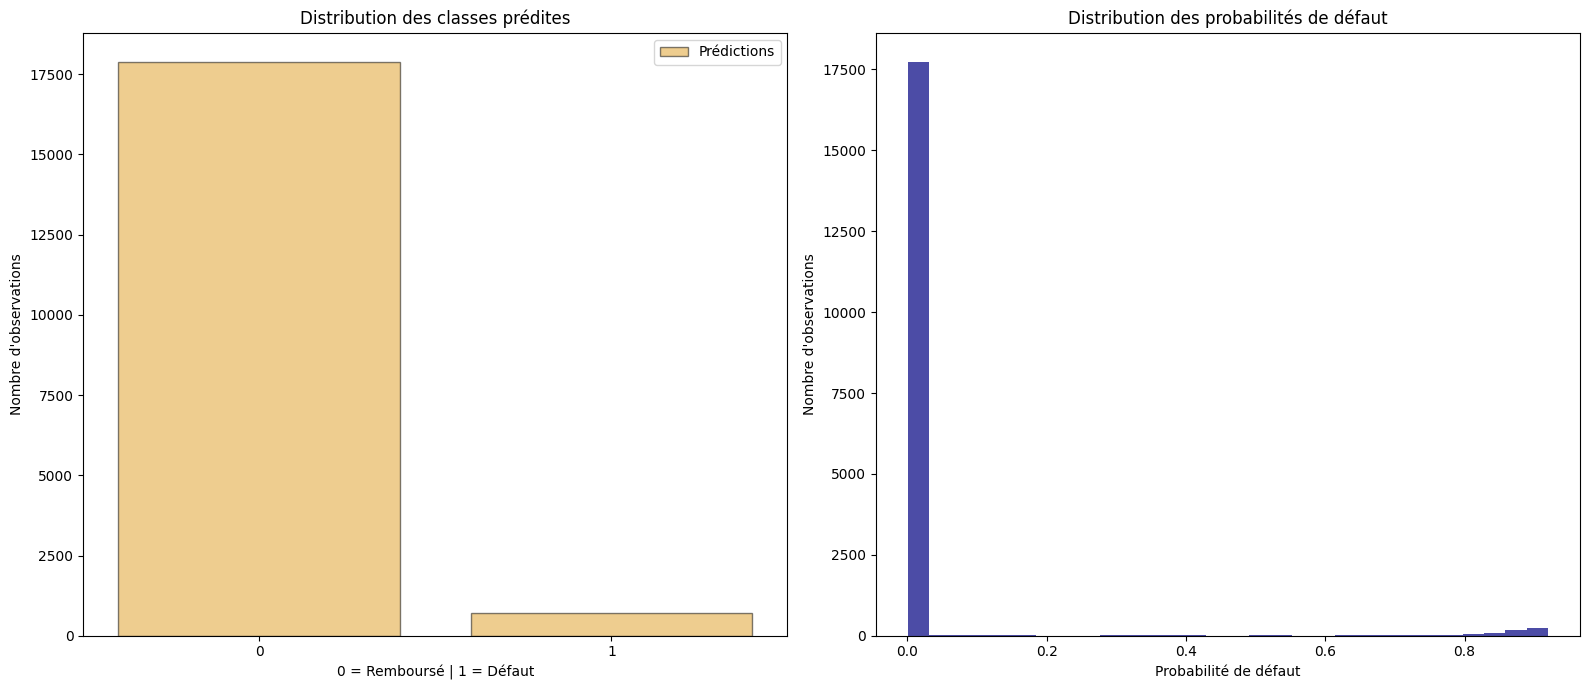

In [139]:
plt.figure(figsize=(16, 7))
plt.subplot(1, 2, 1)
sns.countplot(x=new_df['prediction_default'], color='orange', alpha=0.5, label='Prédictions', edgecolor='black')
plt.legend()
plt.title("Distribution des classes prédites")
plt.xlabel("0 = Remboursé | 1 = Défaut")
plt.ylabel("Nombre d'observations")

plt.subplot(1, 2, 2)
plt.hist(probas, bins=30, alpha=0.7, color='navy')
plt.title("Distribution des probabilités de défaut")
plt.xlabel("Probabilité de défaut")
plt.ylabel("Nombre d'observations")
plt.tight_layout()
plt.show()

# Bulding du pipeline de processing pour l'API

In [ ]:
#from '../API/processing_elements/preprocess.py' import preprocessor

#pipeline = preprocessor(X_train)
#pipeline.fit(X_train)

# Enregistre le preprocess complet
#joblib.dump(pipeline, "../API/processing_elements/preprocess.pkl")

#

In [2]:
!jupyter nbconvert --to html book.ipynb --output ../Docs/Rapport/book.html --allow-errors
!jupyter nbconvert --to pdf book.ipynb --output ../Docs/Rapport/book.pdf --allow-errors
!jupyter nbconvert --to slides book.ipynb --output ../Docs/Rapport/book.slides.html --no-prompt --no-input --allow-errors

/bin/bash: line 1: jupyter: command not found
/bin/bash: line 1: jupyter: command not found
/bin/bash: line 1: jupyter: command not found
